# Lumina: Identity-Aware Photo Selection Pipeline

## Overview
Lumina automates photo curation by identifying individuals across a set of images using ArcFace embeddings, clustering them via HDBSCAN, and picking the best photo per person through a weighted multi-signal scoring model. Scene quality comes from DINOv2 embeddings and NIMA aesthetic scores; face-level signals cover detection confidence, pose, eye-openness (EAR), sharpness, and relative face size.

## Notebook Structure
| Section | Cells | What it does |
|---------|-------|-------------|
| **A — Setup & Config** | 1–4 | Dependencies, imports, configuration |
| **B — Data Loading & EDA** | 5–6 | Image loading, stats, gallery |
| **C — Face Detection & Features** | 7–10 | InsightFace extraction, derived signals |
| **D — Clustering** | 11–14 | HDBSCAN, DBSCAN comparison, evaluation |
| **E — DINOv2 Embeddings** | 15–16 | Scene embeddings, similarity |
| **F — NIMA Aesthetic Scoring** | 17–18 | Aesthetic quality scores |
| **G — Multi-Signal Scoring** | 19–21 | 7-signal ranking, visualizations |
| **H — Evaluation & Analysis** | 22–26 | Ablation, sensitivity, UMAP, correlation |
| **I — Results & Export** | 27–30 | Contact sheets, dashboard, export |

## Models
- **InsightFace buffalo_l** — ArcFace face detection + 512-d embeddings, pose, age/gender, landmarks
- **DINOv2 (ViT-B/14)** — scene-level embeddings for visual quality centrality
- **NIMA** — Neural Image Assessment for aesthetic scoring




In [55]:
# ── Cell 2: Verify Kernel & Dependencies ───────────────────────────────────────
import sys, importlib
print(f"Python: {sys.executable}\n")

_required = {
    "numpy": "1.24", "torch": "2.0", "transformers": "4.0",
    "matplotlib": "3.9", "cv2": "4.10", "insightface": "0.7", "sklearn": "1.0",
    "PIL": "9.0", "tqdm": "4.0", "pandas": "1.0",
    "hdbscan": "0.8", "pyiqa": "0.1", "umap": "0.5", "scipy": "1.10",
    "dotenv": "0.19", "ultralytics": "8.0", "torchreid": "0.1",
}


results = []
all_ok = True
for pkg, min_ver in _required.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "OK")
        results.append((pkg, ver, "PASS"))
    except ImportError:
        results.append((pkg, "\u2014", "FAIL"))
        all_ok = False

print(f"{'Package':<20} {'Version':<16} {'Status'}")
print("\u2500" * 52)
for pkg, ver, status in results:
    mark = "\u2713" if status == "PASS" else "\u2717"
    print(f"  {mark} {pkg:<18} {ver:<16} {status}")

if not all_ok:
    raise RuntimeError("Missing packages \u2014 install via: pip install -r requirements.txt")
print(f"\n{'='*52}")
print(f"All {len(_required)} packages verified \u2014 ready to run.")

Python: c:\Users\agust\AppData\Local\miniconda3\envs\lumina\python.exe

Package              Version          Status
────────────────────────────────────────────────────
  ✓ numpy              2.4.3            PASS
  ✓ torch              2.10.0+cpu       PASS
  ✓ transformers       4.37.2           PASS
  ✓ matplotlib         3.10.8           PASS
  ✓ cv2                4.13.0           PASS
  ✓ insightface        0.7.3            PASS
  ✓ sklearn            1.8.0            PASS
  ✓ PIL                12.1.1           PASS
  ✓ tqdm               4.67.3           PASS
  ✓ pandas             3.0.1            PASS
  ✓ hdbscan            OK               PASS
  ✓ pyiqa              0.1.14.1         PASS
  ✓ umap               0.5.11           PASS
  ✓ scipy              1.17.1           PASS
  ✓ dotenv             OK               PASS
  ✓ ultralytics        8.4.21           PASS
  ✓ torchreid          0.2.5            PASS

All 17 packages verified — ready to run.


In [56]:
# ── Cell 3: Imports, Config, Seed, Device ──────────────────────────────────────
from __future__ import annotations

import json, os, random, shutil, time
from dataclasses import dataclass, fields
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import kendalltau
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel
from dotenv import load_dotenv
from ultralytics import YOLO
import torchreid

# ── Load .env (HF token) ────────────────────────────────────────────────────────
load_dotenv()
hf_token = os.getenv("HF_TOKEN", "").strip() or None
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    os.environ["HUGGINGFACE_HUB_TOKEN"] = hf_token
    print("HF_TOKEN loaded from .env \u2713")
else:
    print("\u26a0 No HF_TOKEN found in .env \u2014 DINOv2 may need token if gated")

# ── Reproducibility ──────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIPELINE_START = time.time()

# ── Config ───────────────────────────────────────────────────────────────────────
@dataclass
class Config:
    image_dir: Path = Path("images")
    output_dir: Path = Path("outputs_ft")

    # DINOv2
    dino_model_id: str = "facebook/dinov2-base"
    dino_batch_size: int = 16

    # InsightFace
    insightface_model: str = "buffalo_l"

    # YOLO person detection
    yolo_model: str = "yolov8n.pt"  # try yolov8m.pt / yolov8l.pt for higher recall (slower)
    # YOLO predict (Ultralytics): tune crowded / overlapping people
    yolo_conf: float = 0.12      # lower -> more boxes (try 0.08–0.15; more false positives)
    yolo_iou: float = 0.88       # higher -> less NMS merging (try 0.85–0.95 for crowds)
    yolo_imgsz: int = 960        # larger -> small/distant people (640/960/1280; slower + more RAM)
    yolo_max_det: int = 100      # raise for dense groups (was 50)
    yolo_augment: bool = True    # test-time augmentation: often +recall, ~slower per image

    # Re-ID (torchreid)
    reid_model_name: str = "osnet_x1_0"
    reid_input_size: tuple = (256, 128)   # (height, width) — standard ReID input

    # HDBSCAN (primary clustering)
    hdbscan_min_cluster_size: int = 2
    hdbscan_min_samples: int = 2

    # DBSCAN (comparison)
    dbscan_eps: float = 0.9
    dbscan_min_samples: int = 2

    # Event clustering (agglomerative): w_scene down-weights DINO block; w_person up-weights co-attendance multi-hot (Cell 14d)
    event_agg_person_weight: float = 3.0

    # 7-signal scoring weights (sum to 1.0)
    w_centrality: float = 0.25
    w_face_sharpness: float = 0.15
    w_face_size: float = 0.10
    w_det_score: float = 0.10
    w_pose: float = 0.10
    w_ear: float = 0.05
    w_nima: float = 0.25


cfg = Config()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

# ── Print full config ────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Device : {DEVICE}")
print(f"  Seed   : {SEED}")
print(f"  Images : {cfg.image_dir.resolve()}")
print(f"  Outputs: {cfg.output_dir.resolve()}")
print(f"{'='*60}")
print(f"\n  Scoring Weights:")
weight_fields = [f for f in fields(cfg) if f.name.startswith("w_")]
for f in weight_fields:
    val = getattr(cfg, f.name)
    bar = "\u2588" * int(val * 40)
    print(f"    {f.name:<20} {val:.2f}  {bar}")
total_w = sum(getattr(cfg, f.name) for f in weight_fields)
status = "\u2713 OK" if abs(total_w - 1.0) < 1e-6 else "\u2717 NOT 1.0!"
print(f"    {'TOTAL':<20} {total_w:.2f}  {status}")
print(f"\n  HDBSCAN: min_cluster_size={cfg.hdbscan_min_cluster_size}, min_samples={cfg.hdbscan_min_samples}")
print(f"  DBSCAN:  eps={cfg.dbscan_eps}, min_samples={cfg.dbscan_min_samples}")

⚠ No HF_TOKEN found in .env — DINOv2 may need token if gated

  Device : cpu
  Seed   : 42
  Images : C:\Users\agust\Documents\AIS Modules\Group Projects\Sem 3\images
  Outputs: C:\Users\agust\Documents\AIS Modules\Group Projects\Sem 3\outputs_ft

  Scoring Weights:
    w_centrality         0.25  ██████████
    w_face_sharpness     0.15  ██████
    w_face_size          0.10  ████
    w_det_score          0.10  ████
    w_pose               0.10  ████
    w_ear                0.05  ██
    w_nima               0.25  ██████████
    TOTAL                1.00  ✓ OK

  HDBSCAN: min_cluster_size=2, min_samples=2
  DBSCAN:  eps=0.9, min_samples=2


---
# Section B: Data Loading & Exploratory Data Analysis

In [57]:
# ── Cell 5: Load Images + Dataset Statistics ───────────────────────────────────
SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff", ".tif"}

image_paths: List[Path] = sorted(
    p for p in cfg.image_dir.iterdir() if p.suffix.lower() in SUPPORTED_EXTS
)

if len(image_paths) == 0:
    raise FileNotFoundError(
        f"No images found in '{cfg.image_dir.resolve()}'.\n"
        "Put your photos in the ./images/ folder and re-run."
    )

# Compute dataset statistics
file_sizes_mb = [p.stat().st_size / (1024 * 1024) for p in image_paths]
resolutions = []
aspect_ratios = []
formats = []
for p in image_paths:
    img = Image.open(p)
    w, h = img.size
    resolutions.append((w, h))
    aspect_ratios.append(w / h)
    formats.append(p.suffix.lower())

widths = [r[0] for r in resolutions]
heights = [r[1] for r in resolutions]

print(f"{'='*60}")
print(f"  Dataset Statistics")
print(f"{'='*60}")
print(f"  Image count      : {len(image_paths)}")
print(f"  File sizes (MB)  : min={min(file_sizes_mb):.2f}  max={max(file_sizes_mb):.2f}  mean={np.mean(file_sizes_mb):.2f}")
print(f"  Widths (px)      : min={min(widths)}  max={max(widths)}  mean={np.mean(widths):.0f}")
print(f"  Heights (px)     : min={min(heights)}  max={max(heights)}  mean={np.mean(heights):.0f}")
print(f"  Aspect ratios    : min={min(aspect_ratios):.2f}  max={max(aspect_ratios):.2f}  mean={np.mean(aspect_ratios):.2f}")
print(f"  Formats          : {dict(pd.Series(formats).value_counts())}")
print(f"{'='*60}")

for p in image_paths[:8]:
    sz = p.stat().st_size / (1024*1024)
    print(f"  {p.name:<30} {sz:.2f} MB")
if len(image_paths) > 8:
    print(f"  ... and {len(image_paths) - 8} more")

  Dataset Statistics
  Image count      : 19
  File sizes (MB)  : min=0.07  max=0.79  mean=0.38
  Widths (px)      : min=320  max=6240  mean=2303
  Heights (px)     : min=325  max=4160  mean=1789
  Aspect ratios    : min=0.75  max=1.78  mean=1.31
  Formats          : {'.jpeg': np.int64(11), '.jpg': np.int64(6), '.png': np.int64(2)}
  DSCF6124.jpg                   0.65 MB
  DSCF6125.jpg                   0.65 MB
  DSCF6126.jpg                   0.65 MB
  Train1.png                     0.79 MB
  Train2.png                     0.16 MB
  Train3.jpeg                    0.07 MB
  Train4.jpg                     0.19 MB
  Train5.jpeg                    0.36 MB
  ... and 11 more


C:\Users\agust\AppData\Local\Temp\ipykernel_4912\3396178777.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


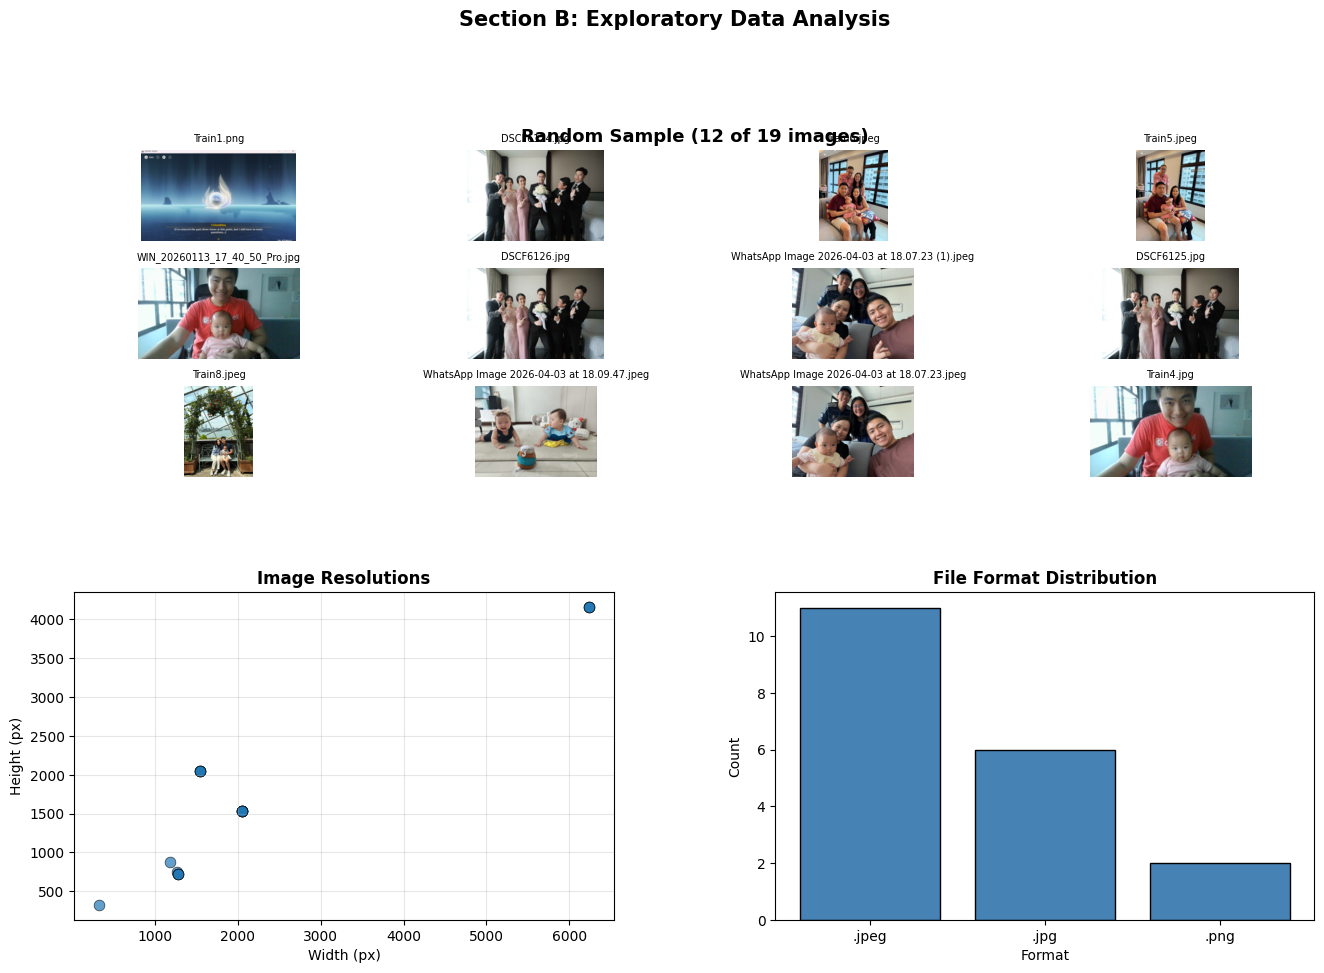

In [58]:
# ── Cell 6: Thumbnail Gallery + Resolution Histogram ─────────────────────────
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# ── Top row: Thumbnail gallery (random sample up to 12) ─────────────────────
ax_gallery = fig.add_subplot(gs[0, :])
sample_n = min(12, len(image_paths))
sample_paths = random.sample(image_paths, sample_n)
cols_g = min(sample_n, 4)
rows_g = (sample_n + cols_g - 1) // cols_g

# Create sub-gridspec for thumbnails
gs_thumbs = gs[0, :].subgridspec(rows_g, cols_g, hspace=0.3, wspace=0.1)
ax_gallery.axis("off")
ax_gallery.set_title(f"Random Sample ({sample_n} of {len(image_paths)} images)", fontsize=13, fontweight="bold")

for i, sp in enumerate(sample_paths):
    ax = fig.add_subplot(gs_thumbs[i // cols_g, i % cols_g])
    img = Image.open(sp).convert("RGB")
    img.thumbnail((200, 200))
    ax.imshow(img)
    ax.set_title(sp.name, fontsize=7)
    ax.axis("off")

# ── Bottom-left: Resolution scatter ───────────────────────────────────────
ax_res = fig.add_subplot(gs[1, 0])
ax_res.scatter(widths, heights, alpha=0.7, edgecolors="black", linewidths=0.5, s=60)
ax_res.set_xlabel("Width (px)")
ax_res.set_ylabel("Height (px)")
ax_res.set_title("Image Resolutions", fontweight="bold")
ax_res.grid(True, alpha=0.3)

# ── Bottom-right: Format distribution ─────────────────────────────────────
ax_fmt = fig.add_subplot(gs[1, 1])
fmt_counts = pd.Series(formats).value_counts()
ax_fmt.bar(fmt_counts.index, fmt_counts.values, color="steelblue", edgecolor="black")
ax_fmt.set_xlabel("Format")
ax_fmt.set_ylabel("Count")
ax_fmt.set_title("File Format Distribution", fontweight="bold")

plt.suptitle("Section B: Exploratory Data Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
# Section C: Face Detection & Feature Extraction

InsightFace `buffalo_l` gives us bounding boxes, 512-d ArcFace embeddings, 5/68/106-point landmarks, pose angles, and age/gender estimates. We derive quality signals (sharpness, EAR, pose penalty, face size ratio) from these.


In [59]:
# ── Cell 8: InsightFace — Extract ALL Face Attributes ────────────────────────
from insightface.app import FaceAnalysis

providers = (
    ["CUDAExecutionProvider", "CPUExecutionProvider"]
    if torch.cuda.is_available()
    else ["CPUExecutionProvider"]
)

face_app = FaceAnalysis(name=cfg.insightface_model, providers=providers)
face_app.prepare(
    ctx_id=0 if torch.cuda.is_available() else -1,
    det_size=(640, 640),
)
print(f"InsightFace model loaded: {cfg.insightface_model}\n")

# ── Detect faces and extract ALL available attributes ──────────────────────
face_records: List[dict] = []
no_face_paths: List[Path] = []

for path in tqdm(image_paths, desc="Detecting faces"):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        no_face_paths.append(path)
        continue

    h, w = img_bgr.shape[:2]
    faces = face_app.get(img_bgr)
    if len(faces) == 0:
        no_face_paths.append(path)
        continue

    for fi, face in enumerate(faces):
        if face.embedding is None:
            continue
        emb = face.embedding.astype(np.float32)
        norm = np.linalg.norm(emb)
        if norm > 0:
            emb = emb / norm

        rec = {
            "photo_path": path,
            "image_hw": (h, w),
            "face_idx": fi,
            "embedding": emb,
            "bbox": face.bbox.tolist(),
            "det_score": float(face.det_score),
            "kps": face.kps.tolist() if face.kps is not None else None,
        }

        # Pose (pitch, yaw, roll) \u2014 available in buffalo_l
        if hasattr(face, "pose") and face.pose is not None:
            rec["pose"] = face.pose.tolist()  # [pitch, yaw, roll] in degrees
        else:
            rec["pose"] = [0.0, 0.0, 0.0]

        # Age & Gender
        rec["age"] = int(face.age) if hasattr(face, "age") and face.age is not None else None
        rec["gender"] = int(face.gender) if hasattr(face, "gender") and face.gender is not None else None

        # 68-point 3D landmarks
        if hasattr(face, "landmark_3d_68") and face.landmark_3d_68 is not None:
            rec["landmark_3d_68"] = face.landmark_3d_68.tolist()
        else:
            rec["landmark_3d_68"] = None

        # 106-point 2D landmarks
        if hasattr(face, "landmark_2d_106") and face.landmark_2d_106 is not None:
            rec["landmark_2d_106"] = face.landmark_2d_106.tolist()
        else:
            rec["landmark_2d_106"] = None

        face_records.append(rec)

# ── Verbose statistics ───────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Face Detection Results")
print(f"{'='*60}")
print(f"  Total faces detected   : {len(face_records)}")
print(f"  Photos with faces      : {len(image_paths) - len(no_face_paths)}")
print(f"  Photos with no face    : {len(no_face_paths)}")

# Faces per image
faces_per_img = {}
for rec in face_records:
    k = str(rec["photo_path"])
    faces_per_img[k] = faces_per_img.get(k, 0) + 1
fpi_vals = list(faces_per_img.values())
if fpi_vals:
    print(f"  Faces per image        : min={min(fpi_vals)}  max={max(fpi_vals)}  mean={np.mean(fpi_vals):.1f}")

# Det score stats
det_scores = [r["det_score"] for r in face_records]
if det_scores:
    print(f"  Det score              : min={min(det_scores):.3f}  max={max(det_scores):.3f}  mean={np.mean(det_scores):.3f}")

# Age distribution
ages = [r["age"] for r in face_records if r["age"] is not None]
if ages:
    print(f"  Age range              : {min(ages)}\u2013{max(ages)}  mean={np.mean(ages):.1f}")

# Gender breakdown
genders = [r["gender"] for r in face_records if r["gender"] is not None]
if genders:
    n_male = sum(1 for g in genders if g == 1)
    n_female = sum(1 for g in genders if g == 0)
    print(f"  Gender (M/F)           : {n_male} / {n_female}")

# Landmark availability
n_lm68 = sum(1 for r in face_records if r["landmark_3d_68"] is not None)
n_lm106 = sum(1 for r in face_records if r["landmark_2d_106"] is not None)
print(f"  68-pt landmarks        : {n_lm68}/{len(face_records)}")
print(f"  106-pt landmarks       : {n_lm106}/{len(face_records)}")
print(f"{'='*60}")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\agust/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\agust/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\agust/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\agust/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\agust/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

Detecting faces:   0%|          | 0/19 [00:00<?, ?it/s]c:\Users\agust\AppData\Local\miniconda3\envs\lumina\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Detecting faces: 100%|██████████| 19/19 [00:08<00:00,  2.26it/s]


  Face Detection Results
  Total faces detected   : 60
  Photos with faces      : 17
  Photos with no face    : 2
  Faces per image        : min=1  max=6  mean=3.5
  Det score              : min=0.670  max=0.918  mean=0.855
  Age range              : 1–71  mean=29.0
  Gender (M/F)           : 36 / 24
  68-pt landmarks        : 60/60
  106-pt landmarks       : 60/60


In [60]:
# ── Cell 9: Compute Derived Face Quality Signals ─────────────────────────────
# For each face, compute 6 quality signals from the raw InsightFace attributes.

def compute_pose_penalty(pose: List[float]) -> float:
    """1.0 = perfectly frontal, 0.0 = extreme non-frontal.
    pose = [pitch, yaw, roll] in degrees."""
    pitch, yaw, roll = [abs(v) for v in pose]
    penalty = 1.0 - (yaw / 90.0) * 0.5 - (pitch / 90.0) * 0.3 - (roll / 45.0) * 0.2
    return float(np.clip(penalty, 0.0, 1.0))


def compute_ear(landmarks_68: list) -> float:
    """Eye Aspect Ratio from 68-point landmarks (points 36-47).
    EAR = (||p37-p41|| + ||p38-p40||) / (2 * ||p36-p39||)
    Averaged over both eyes. Low EAR = eyes closed."""
    if landmarks_68 is None:
        return 0.5  # neutral default
    pts = np.array(landmarks_68)[:, :2]  # take x,y only (drop z if 3D)
    
    def _eye_ear(p):
        vertical1 = np.linalg.norm(p[1] - p[5])
        vertical2 = np.linalg.norm(p[2] - p[4])
        horizontal = np.linalg.norm(p[0] - p[3])
        if horizontal < 1e-6:
            return 0.5
        return (vertical1 + vertical2) / (2.0 * horizontal)
    
    # Left eye: points 36-41, Right eye: points 42-47
    left_ear = _eye_ear(pts[36:42])
    right_ear = _eye_ear(pts[42:48])
    return float((left_ear + right_ear) / 2.0)


def compute_smile_score(landmarks_68: list) -> float:
    """Smile score from 68-point landmarks.
    Mouth corners (48, 54) lift relative to upper lip center (51)."""
    if landmarks_68 is None:
        return 0.5
    pts = np.array(landmarks_68)[:, :2]
    left_corner = pts[48]
    right_corner = pts[54]
    upper_lip_center = pts[51]
    # Smile: corners are higher (lower y value) relative to lip center
    corner_avg_y = (left_corner[1] + right_corner[1]) / 2.0
    mouth_width = np.linalg.norm(left_corner - right_corner)
    if mouth_width < 1e-6:
        return 0.5
    lift = (upper_lip_center[1] - corner_avg_y) / mouth_width
    return float(np.clip(lift + 0.5, 0.0, 1.0))


def compute_face_sharpness(img_bgr: np.ndarray, bbox: list) -> float:
    """Laplacian variance on face crop."""
    h, w = img_bgr.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return 0.0
    crop = img_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return 0.0
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def compute_face_size_ratio(bbox: list, image_hw: tuple) -> float:
    """Face bbox area / image area."""
    h, w = image_hw
    x1, y1, x2, y2 = bbox
    face_area = max(0, x2 - x1) * max(0, y2 - y1)
    img_area = max(h * w, 1)
    return float(face_area / img_area)


# ── Apply all signals to every face record ─────────────────────────────────
# Cache loaded images to avoid re-reading
_img_cache: Dict[str, np.ndarray] = {}

for rec in tqdm(face_records, desc="Computing face signals"):
    path_str = str(rec["photo_path"])
    if path_str not in _img_cache:
        _img_cache[path_str] = cv2.imread(path_str)
    img_bgr = _img_cache[path_str]

    rec["pose_penalty"] = compute_pose_penalty(rec["pose"])
    rec["ear"] = compute_ear(rec["landmark_3d_68"])
    rec["smile_score"] = compute_smile_score(rec["landmark_3d_68"])
    rec["face_sharpness"] = compute_face_sharpness(img_bgr, rec["bbox"]) if img_bgr is not None else 0.0
    rec["face_size_ratio"] = compute_face_size_ratio(rec["bbox"], rec["image_hw"])

del _img_cache  # free memory

# ── Summary statistics per signal ──────────────────────────────────────────
signal_names = ["det_score", "pose_penalty", "ear", "smile_score", "face_sharpness", "face_size_ratio"]
print(f"\n{'Signal':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("\u2500" * 56)
for sig in signal_names:
    vals = [r[sig] for r in face_records]
    print(f"  {sig:<18} {np.mean(vals):8.4f} {np.std(vals):8.4f} {np.min(vals):8.4f} {np.max(vals):8.4f}")

Computing face signals: 100%|██████████| 60/60 [00:00<00:00, 130.72it/s]


Signal                   Mean      Std      Min      Max
────────────────────────────────────────────────────────
  det_score            0.8548   0.0546   0.6699   0.9179
  pose_penalty         0.8286   0.1566   0.3260   0.9684
  ear                  0.2934   0.1096   0.1477   0.7144
  smile_score          0.3439   0.1176   0.0000   0.5719
  face_sharpness     183.8100 157.2730  20.3458 713.4405
  face_size_ratio      0.0196   0.0239   0.0016   0.1187


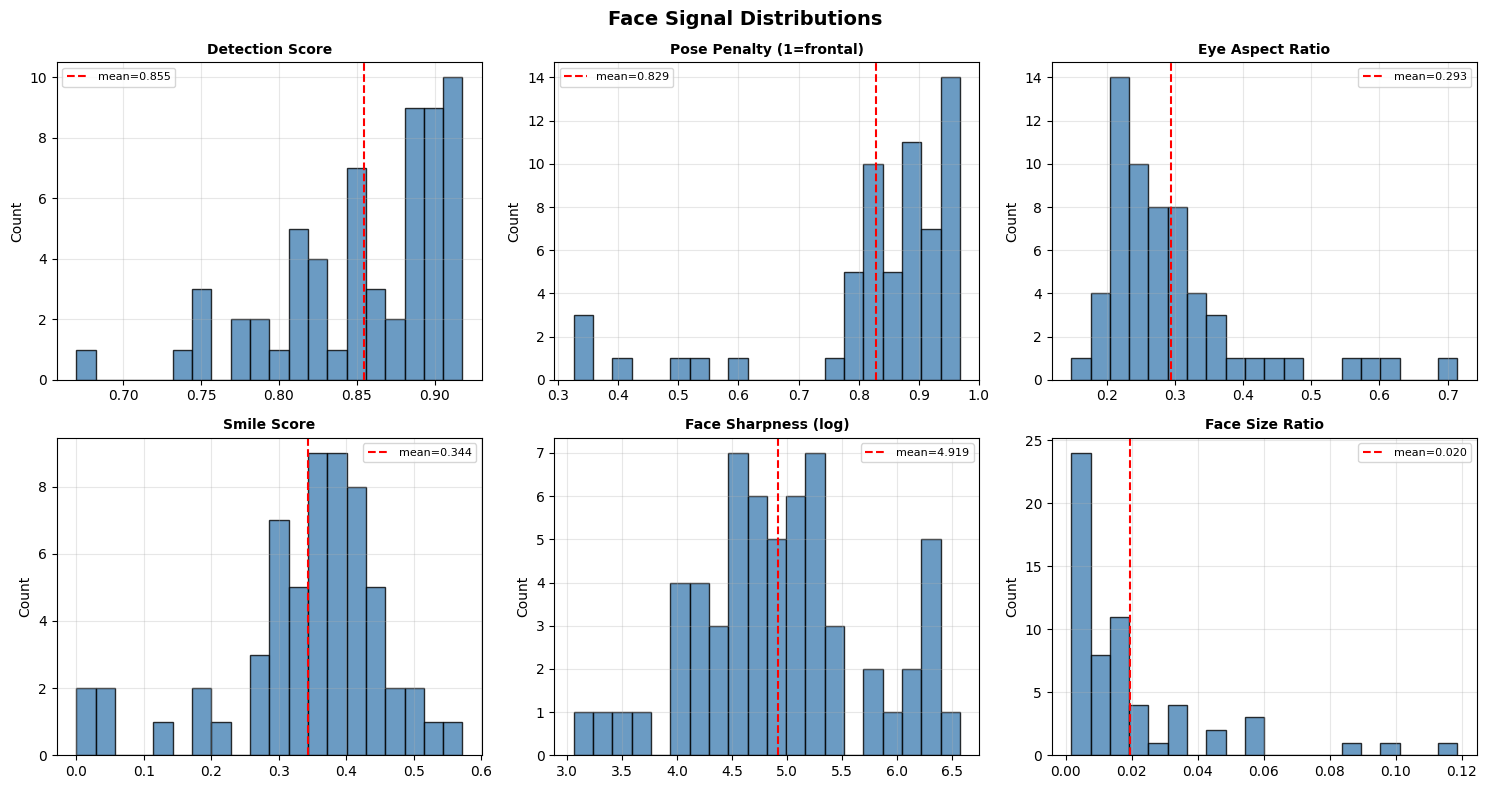

In [61]:
# ── Cell 10: Face Signal Distribution Plots ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

signal_configs = [
    ("det_score", "Detection Score", False),
    ("pose_penalty", "Pose Penalty (1=frontal)", False),
    ("ear", "Eye Aspect Ratio", False),
    ("smile_score", "Smile Score", False),
    ("face_sharpness", "Face Sharpness (log)", True),
    ("face_size_ratio", "Face Size Ratio", False),
]

for ax, (sig, title, use_log) in zip(axes, signal_configs):
    vals = [r[sig] for r in face_records]
    if use_log:
        vals = [np.log1p(v) for v in vals]
    ax.hist(vals, bins=20, color="steelblue", edgecolor="black", alpha=0.8)
    mean_val = np.mean(vals)
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"mean={mean_val:.3f}")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Face Signal Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [62]:
# ── Cell 11a: YOLO Person Detection ───────────────────────────────────────────
# Detect all persons in every image using YOLOv8.
# These bounding boxes are the crops fed into torchreid for appearance embeddings.

yolo_model = YOLO(cfg.yolo_model)  # downloads yolov8n.pt on first run

person_detections: List[dict] = []

for path in tqdm(image_paths, desc="YOLO — detecting persons"):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        continue
    h, w = img_bgr.shape[:2]
    results = yolo_model(
        img_bgr,
        classes=[0],
        verbose=False,
        conf=cfg.yolo_conf,
        iou=cfg.yolo_iou,
        imgsz=cfg.yolo_imgsz,
        max_det=cfg.yolo_max_det,
        augment=cfg.yolo_augment,
    )  # class 0 = person
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            person_detections.append({
                "photo_path": path,
                "image_hw": (h, w),
                "bbox": [x1, y1, x2, y2],
                "yolo_conf": conf,
                "reid_embedding": None,
                "face_record": None,
                "person_id": None,
            })

print(f"\n{'='*60}")
print(f"  YOLO Person Detection Results")
print(f"  infer: conf={cfg.yolo_conf}, iou={cfg.yolo_iou}, imgsz={cfg.yolo_imgsz}, max_det={cfg.yolo_max_det}, augment={cfg.yolo_augment}")
print(f"{'='*60}")
print(f"  Total person instances : {len(person_detections)}")

images_with_persons = len(set(str(r["photo_path"]) for r in person_detections))
print(f"  Images with persons    : {images_with_persons} / {len(image_paths)}")

if person_detections:
    confs = [r["yolo_conf"] for r in person_detections]
    print(f"  Confidence             : min={min(confs):.3f}  max={max(confs):.3f}  mean={sum(confs)/len(confs):.3f}")

    per_img = {}
    for r in person_detections:
        k = str(r["photo_path"])
        per_img[k] = per_img.get(k, 0) + 1
    vals = list(per_img.values())
    print(f"  Persons per image      : min={min(vals)}  max={max(vals)}  mean={sum(vals)/len(vals):.1f}")
print(f"{'='*60}")

YOLO — detecting persons: 100%|██████████| 19/19 [00:04<00:00,  3.97it/s]


  YOLO Person Detection Results
  infer: conf=0.12, iou=0.88, imgsz=960, max_det=100, augment=True
  Total person instances : 129
  Images with persons    : 16 / 19
  Confidence             : min=0.124  max=0.929  mean=0.538
  Persons per image      : min=2  max=19  mean=8.1


In [63]:
# ── Cell 11b: torchreid Body Embeddings + Face Linkage ────────────────────────
# 1. Extract 512-d appearance embeddings (OSNet) from each YOLO person crop.
# 2. Link each person detection to the InsightFace face record whose center
#    falls inside the person bounding box (for quality signals later).

# ── Build OSNet model ─────────────────────────────────────────────────────────
reid_model = torchreid.models.build_model(
    name=cfg.reid_model_name,
    num_classes=1000,
    pretrained=True,
    use_gpu=torch.cuda.is_available(),
)
reid_model.eval()
if torch.cuda.is_available():
    reid_model = reid_model.cuda()

reid_transform = T.Compose([
    T.Resize(cfg.reid_input_size),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_reid_embedding(img_bgr: np.ndarray, bbox: list):
    """Crop person bounding box and return L2-normalised OSNet embedding."""
    h, w = img_bgr.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 <= x1 + 10 or y2 <= y1 + 10:
        return None
    crop = img_bgr[y1:y2, x1:x2]
    pil_crop = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    tensor = reid_transform(pil_crop).unsqueeze(0)
    if torch.cuda.is_available():
        tensor = tensor.cuda()
    with torch.no_grad():
        feat = reid_model(tensor).cpu().numpy().squeeze()
    norm = np.linalg.norm(feat)
    return feat / (norm + 1e-12)

# ── Extract embeddings ────────────────────────────────────────────────────────
_img_cache_reid: Dict[str, np.ndarray] = {}
for prec in tqdm(person_detections, desc="torchreid — extracting embeddings"):
    path_str = str(prec["photo_path"])
    if path_str not in _img_cache_reid:
        _img_cache_reid[path_str] = cv2.imread(path_str)
    img_bgr = _img_cache_reid[path_str]
    prec["reid_embedding"] = extract_reid_embedding(img_bgr, prec["bbox"]) if img_bgr is not None else None

del _img_cache_reid

# Drop detections where embedding failed
before = len(person_detections)
person_detections = [r for r in person_detections if r["reid_embedding"] is not None]
print(f"Embeddings extracted: {len(person_detections)} / {before}")

# ── Link persons → InsightFace face records ───────────────────────────────────
def face_center_in_box(face_bbox: list, person_bbox: list) -> bool:
    """True if face centre falls inside the person bounding box."""
    fx1, fy1, fx2, fy2 = face_bbox
    cx, cy = (fx1 + fx2) / 2, (fy1 + fy2) / 2
    px1, py1, px2, py2 = person_bbox
    return px1 <= cx <= px2 and py1 <= cy <= py2

face_by_path: Dict[str, List[dict]] = {}
for frec in face_records:
    face_by_path.setdefault(str(frec["photo_path"]), []).append(frec)

for prec in person_detections:
    for frec in face_by_path.get(str(prec["photo_path"]), []):
        if face_center_in_box(frec["bbox"], prec["bbox"]):
            prec["face_record"] = frec
            break

n_linked = sum(1 for r in person_detections if r["face_record"] is not None)
print(f"\n{'='*60}")
print(f"  torchreid + Face Linkage Summary")
print(f"{'='*60}")
print(f"  Person detections      : {len(person_detections)}")
print(f"  Linked to a face       : {n_linked}  ({100*n_linked/max(1,len(person_detections)):.1f}%)")
print(f"  Body-only (no face)    : {len(person_detections) - n_linked}")

reid_embeddings = np.stack([r["reid_embedding"] for r in person_detections])
print(f"  reid_embeddings shape  : {reid_embeddings.shape}  (N_persons × 512)")
print(f"{'='*60}")

Successfully loaded imagenet pretrained weights from "C:\Users\agust/.cache\torch\checkpoints\osnet_x1_0_imagenet.pth"


torchreid — extracting embeddings: 100%|██████████| 129/129 [00:06<00:00, 20.53it/s]

Embeddings extracted: 129 / 129

  torchreid + Face Linkage Summary
  Person detections      : 129
  Linked to a face       : 121  (93.8%)
  Body-only (no face)    : 8
  reid_embeddings shape  : (129, 512)  (N_persons × 512)


---
# Section D: Identity Clustering

We cluster L2-normalised torchreid body embeddings with HDBSCAN (primary) and compare against DBSCAN at various epsilon values. HDBSCAN picks its own density threshold and handles noise; DBSCAN needs a fixed eps. Evaluation uses Silhouette, Calinski-Harabasz, and Davies-Bouldin indices.


In [64]:
# ── Cell 12: HDBSCAN Clustering (Primary) ────────────────────────────────────
import hdbscan

def minmax_norm(arr: np.ndarray) -> np.ndarray:
    """Min-max normalize to [0,1]. Returns ones if constant."""
    arr = np.asarray(arr, dtype=np.float32)
    mn, mx = arr.min(), arr.max()
    if float(mx - mn) < 1e-12:
        return np.ones_like(arr)
    return (arr - mn) / (mx - mn)


if len(person_detections) == 0:
    raise RuntimeError("No persons detected — cannot cluster.")

# reid_embeddings built in Cell 11b: shape (N_persons, 512) from torchreid OSNet.
# InsightFace embeddings are still used downstream for photo quality signals only.

# ── HDBSCAN ──────────────────────────────────────────────────────────────────
hdb = hdbscan.HDBSCAN(
    min_cluster_size=cfg.hdbscan_min_cluster_size,
    min_samples=cfg.hdbscan_min_samples,
    metric="euclidean",
    cluster_selection_method="eom",
)
hdb_labels = hdb.fit_predict(reid_embeddings)
hdb_probs = hdb.probabilities_

n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_hdb_noise = int((hdb_labels == -1).sum())

print(f"{'='*60}")
print(f"  HDBSCAN Results")
print(f"{'='*60}")
print(f"  Clusters found     : {n_hdb_clusters}")
print(f"  Noise faces        : {n_hdb_noise}")

# Reassign noise faces to nearest cluster centroid
if n_hdb_noise > 0 and n_hdb_clusters > 0:
    cluster_ids = [c for c in set(hdb_labels) if c >= 0]
    centroids = {}
    for c in cluster_ids:
        mask = hdb_labels == c
        centroids[c] = reid_embeddings[mask].mean(axis=0)

    for i in range(len(hdb_labels)):
        if hdb_labels[i] == -1:
            dists = {c: np.linalg.norm(reid_embeddings[i] - cent) for c, cent in centroids.items()}
            hdb_labels[i] = min(dists, key=dists.get)
    
    n_reassigned = n_hdb_noise
    n_hdb_noise_after = int((hdb_labels == -1).sum())
    print(f"  Noise reassigned   : {n_reassigned} → nearest centroid")
    print(f"  Noise remaining    : {n_hdb_noise_after}")

# Cluster sizes
from collections import Counter
hdb_counts = Counter(hdb_labels)
print(f"\n  Cluster sizes:")
for cid in sorted(hdb_counts):
    if cid < 0:
        continue
    print(f"    Cluster {cid}: {hdb_counts[cid]} faces")

# Membership probabilities
print(f"\n  Membership probabilities:")
print(f"    min={hdb_probs.min():.3f}  max={hdb_probs.max():.3f}  mean={hdb_probs.mean():.3f}")
print(f"{'='*60}")

  HDBSCAN Results
  Clusters found     : 18
  Noise faces        : 23
  Noise reassigned   : 23 → nearest centroid
  Noise remaining    : 0

  Cluster sizes:
    Cluster 0: 3 faces
    Cluster 1: 3 faces
    Cluster 2: 3 faces
    Cluster 3: 3 faces
    Cluster 4: 8 faces
    Cluster 5: 3 faces
    Cluster 6: 7 faces
    Cluster 7: 8 faces
    Cluster 8: 3 faces
    Cluster 9: 7 faces
    Cluster 10: 32 faces
    Cluster 11: 7 faces
    Cluster 12: 3 faces
    Cluster 13: 5 faces
    Cluster 14: 4 faces
    Cluster 15: 7 faces
    Cluster 16: 18 faces
    Cluster 17: 5 faces

  Membership probabilities:
    min=0.000  max=1.000  mean=0.782


DBSCAN eps sweep: 21 values tested, 18 had valid metrics

   eps  n_clusters  n_noise  silhouette  calinski_harabasz  davies_bouldin
0.2000           4      120      0.7868            55.6020          0.2236
0.2500           7      111      0.7080            44.2590          0.3266
0.3000          19       86      0.5479            29.7610          0.5318
0.3500          32       47      0.4368            20.6350          0.7061
0.4000          30       31      0.4105            18.4722          0.7838
0.4500          26       20      0.3689            15.4517          0.8903
0.5000          25       14      0.3545            13.8722          0.9183
0.5500          21        7      0.3382            11.0093          0.9781
0.6000          21        3      0.3263            11.0894          1.0211
0.6500          16        1      0.2272             7.2297          1.0895
0.7000          16        1      0.2272             7.2297          1.0895
0.7500          11        1      0.1950   

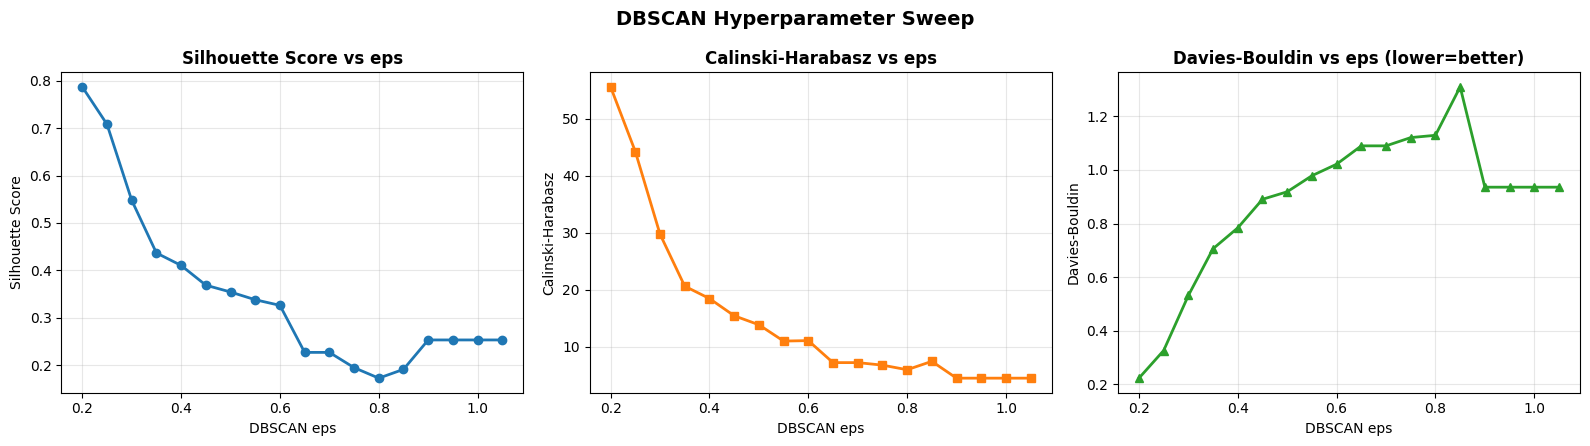


Optimal DBSCAN eps = 0.20 (silhouette = 0.7868)


In [65]:
# ── Cell 13: DBSCAN Comparison + Silhouette Sweep ────────────────────────────
eps_values = np.arange(0.2, 1.25, 0.05)
sweep_results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=cfg.dbscan_min_samples, metric="euclidean", n_jobs=-1)
    labels = db.fit_predict(reid_embeddings)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())

    if n_clusters >= 2 and n_noise < len(labels) - 1:
        mask = labels >= 0
        if mask.sum() > n_clusters:
            sil = silhouette_score(reid_embeddings[mask], labels[mask])
            ch = calinski_harabasz_score(reid_embeddings[mask], labels[mask])
            db_score = davies_bouldin_score(reid_embeddings[mask], labels[mask])
        else:
            sil, ch, db_score = float("nan"), float("nan"), float("nan")
    else:
        sil, ch, db_score = float("nan"), float("nan"), float("nan")
    
    sweep_results.append({
        "eps": eps, "n_clusters": n_clusters, "n_noise": n_noise,
        "silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db_score,
    })

sweep_df = pd.DataFrame(sweep_results)
valid_sweep = sweep_df.dropna(subset=["silhouette"])

print(f"DBSCAN eps sweep: {len(eps_values)} values tested, {len(valid_sweep)} had valid metrics\n")
print(sweep_df.to_string(index=False, float_format="%.4f"))

# ── Plot ─────────────────────────────────────────────────────────────────────
if not valid_sweep.empty:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))
    
    ax1.plot(valid_sweep["eps"], valid_sweep["silhouette"], "o-", color="tab:blue", linewidth=2)
    ax1.set_xlabel("DBSCAN eps")
    ax1.set_ylabel("Silhouette Score")
    ax1.set_title("Silhouette Score vs eps", fontweight="bold")
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(valid_sweep["eps"], valid_sweep["calinski_harabasz"], "s-", color="tab:orange", linewidth=2)
    ax2.set_xlabel("DBSCAN eps")
    ax2.set_ylabel("Calinski-Harabasz")
    ax2.set_title("Calinski-Harabasz vs eps", fontweight="bold")
    ax2.grid(True, alpha=0.3)
    
    ax3.plot(valid_sweep["eps"], valid_sweep["davies_bouldin"], "^-", color="tab:green", linewidth=2)
    ax3.set_xlabel("DBSCAN eps")
    ax3.set_ylabel("Davies-Bouldin")
    ax3.set_title("Davies-Bouldin vs eps (lower=better)", fontweight="bold")
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle("DBSCAN Hyperparameter Sweep", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    # Find optimal eps (highest silhouette)
    best_row = valid_sweep.loc[valid_sweep["silhouette"].idxmax()]
    print(f"\nOptimal DBSCAN eps = {best_row['eps']:.2f} (silhouette = {best_row['silhouette']:.4f})")
else:
    print("No valid clustering results — dataset may be too small for DBSCAN sweep.")
    best_row = None

In [66]:
# ── Cell 14: Clustering Evaluation Summary ───────────────────────────────────
# Compare HDBSCAN vs DBSCAN-optimal vs DBSCAN-default

def evaluate_clustering(embeddings, labels, name):
    """Compute clustering metrics for given labels."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    mask = labels >= 0

    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(embeddings[mask], labels[mask])
        ch = calinski_harabasz_score(embeddings[mask], labels[mask])
        dbi = davies_bouldin_score(embeddings[mask], labels[mask])
    else:
        sil, ch, dbi = float("nan"), float("nan"), float("nan")

    return {"Method": name, "Clusters": n_clusters, "Noise": n_noise,
            "Silhouette": sil, "Calinski-Harabasz": ch, "Davies-Bouldin": dbi}


comparison_rows = []

# 1. HDBSCAN (on torchreid body embeddings)
comparison_rows.append(evaluate_clustering(reid_embeddings, hdb_labels, "HDBSCAN (ReID)"))

# 2. DBSCAN-optimal (from sweep)
if best_row is not None:
    db_opt = DBSCAN(eps=best_row["eps"], min_samples=cfg.dbscan_min_samples, metric="euclidean", n_jobs=-1)
    db_opt_labels = db_opt.fit_predict(reid_embeddings)
    comparison_rows.append(evaluate_clustering(reid_embeddings, db_opt_labels, f"DBSCAN-opt (eps={best_row['eps']:.2f})"))

# 3. DBSCAN-default
db_def = DBSCAN(eps=cfg.dbscan_eps, min_samples=cfg.dbscan_min_samples, metric="euclidean", n_jobs=-1)
db_def_labels = db_def.fit_predict(reid_embeddings)
comparison_rows.append(evaluate_clustering(reid_embeddings, db_def_labels, f"DBSCAN-def (eps={cfg.dbscan_eps})"))

comp_df = pd.DataFrame(comparison_rows)
print("Clustering Method Comparison (torchreid body embeddings):")
print("=" * 80)
print(comp_df.to_string(index=False, float_format="%.4f"))
print("=" * 80)

# ── Select winner: HDBSCAN on torchreid embeddings ──────────────────────────
person_labels = hdb_labels.copy()
clustering_method = "HDBSCAN (torchreid body + face)"

# Attach person_id to each person_detection and propagate to its linked face_record.
# face_records retain InsightFace quality signals; only identity assignment changes.
for i, prec in enumerate(person_detections):
    lbl = int(person_labels[i])
    pid = f"person_{lbl}" if lbl >= 0 else None
    prec["person_id"] = pid
    if prec["face_record"] is not None:
        prec["face_record"]["person_id"] = pid

# face_labels: backward-compatible array aligned with face_records
face_labels = np.array([rec.get("person_id", None) for rec in face_records])

# Build identity_map: person_id → unique photo paths
identity_map: Dict[str, List[Path]] = {}
for prec in person_detections:
    if prec["person_id"] is None:
        continue
    pid = prec["person_id"]
    path = prec["photo_path"]
    if pid not in identity_map:
        identity_map[pid] = []
    if path not in identity_map[pid]:
        identity_map[pid].append(path)

identity_map = dict(sorted(identity_map.items(), key=lambda kv: len(kv[1]), reverse=True))

print(f"\n✓ Clustering method : {clustering_method}")
print(f"  Identity groups   : {len(identity_map)}")
for pid, photos in identity_map.items():
    print(f"    {pid}: {len(photos)} photos")

Clustering Method Comparison (torchreid body embeddings):
               Method  Clusters  Noise  Silhouette  Calinski-Harabasz  Davies-Bouldin
       HDBSCAN (ReID)        18      0      0.2542             9.2786          1.2555
DBSCAN-opt (eps=0.20)         4    120      0.7868            55.6020          0.2236
 DBSCAN-def (eps=0.9)         2      0      0.2534             4.5029          0.9354

✓ Clustering method : HDBSCAN (torchreid body + face)
  Identity groups   : 18
    person_16: 6 photos
    person_6: 4 photos
    person_7: 4 photos
    person_0: 3 photos
    person_2: 3 photos
    person_1: 3 photos
    person_5: 3 photos
    person_3: 3 photos
    person_12: 3 photos
    person_11: 3 photos
    person_4: 3 photos
    person_10: 3 photos
    person_14: 3 photos
    person_8: 3 photos
    person_9: 3 photos
    person_13: 2 photos
    person_17: 2 photos
    person_15: 2 photos


  CLUSTER RESULTS  —  18 groups found
  Clustering basis: torchreid body appearance (face + clothing)

  Cluster 1  (id=16)  —  6 photo(s)
  ────────────────────────────────────────────────────────────
    Train4.jpg
    Train5.jpeg
    Train6.jpeg
    WhatsApp Image 2026-04-03 at 18.07.23 (1).jpeg
    WhatsApp Image 2026-04-03 at 18.07.23.jpeg
    WhatsApp Image 2026-04-03 at 18.07.24.jpeg

  Cluster 2  (id=6)  —  4 photo(s)
  ────────────────────────────────────────────────────────────
    DSCF6124.jpg
    DSCF6125.jpg
    DSCF6126.jpg
    Train4.jpg

  Cluster 3  (id=7)  —  4 photo(s)
  ────────────────────────────────────────────────────────────
    Train6.jpeg
    WhatsApp Image 2026-04-03 at 18.07.23 (1).jpeg
    WhatsApp Image 2026-04-03 at 18.07.23.jpeg
    WhatsApp Image 2026-04-03 at 18.07.24.jpeg

  Cluster 4  (id=0)  —  3 photo(s)
  ────────────────────────────────────────────────────────────
    DSCF6124.jpg
    DSCF6125.jpg
    DSCF6126.jpg

  Cluster 5  (id=2)  —  3 phot

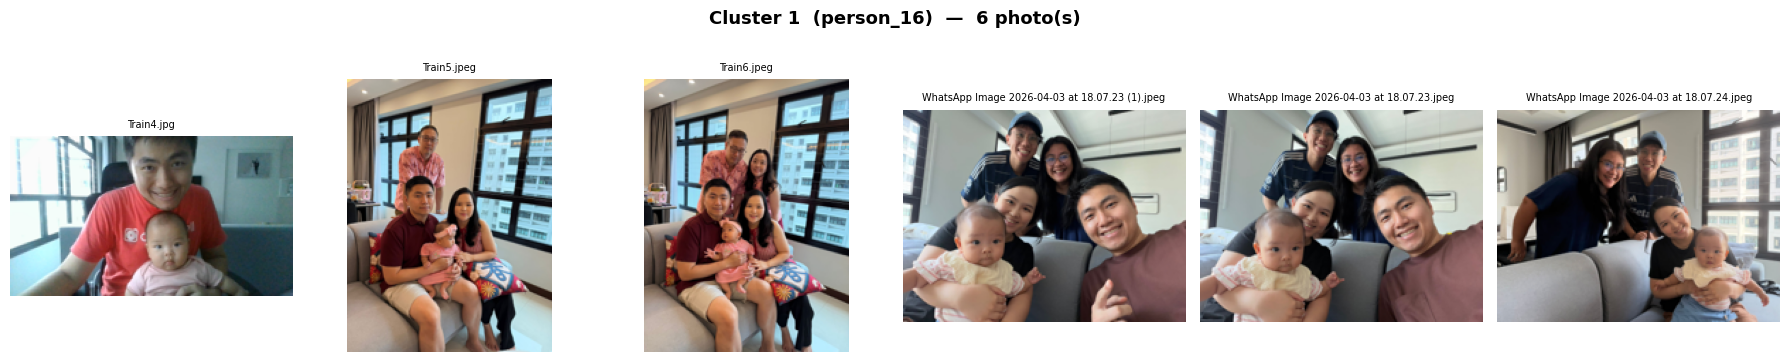

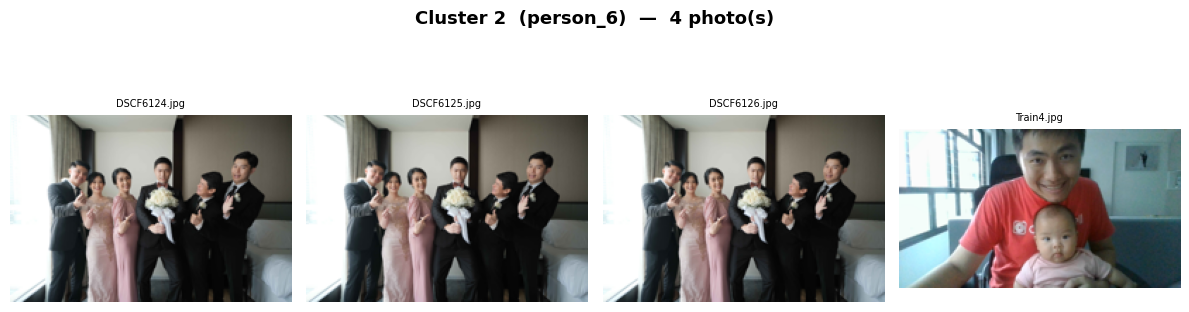

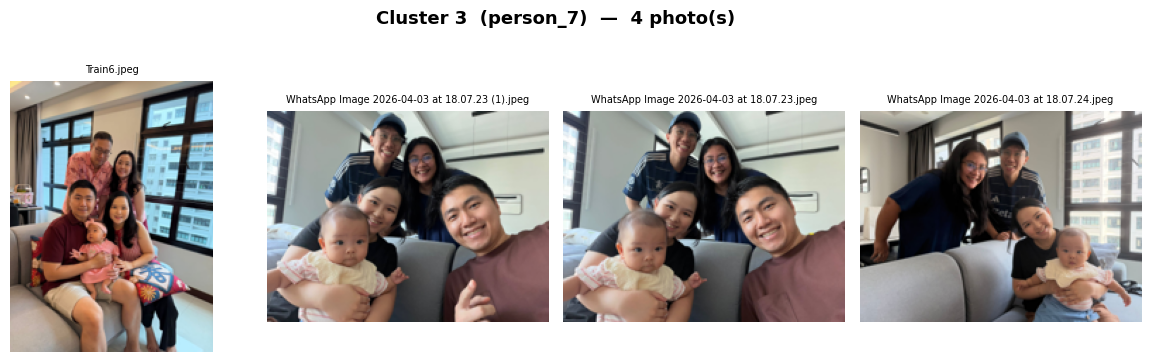

In [67]:
# ── Cell 14b: Cluster → Photo List + Visual Preview (first 3 clusters) ────────
# Each cluster = a group of photos likely from the same event
# (same/similar people wearing the same clothes).

PREVIEW_CLUSTERS = 3   # number of clusters to show visually
THUMB_SIZE       = (200, 200)  # thumbnail size per image

print(f"{'='*70}")
print(f"  CLUSTER RESULTS  —  {len(identity_map)} groups found")
print(f"  Clustering basis: torchreid body appearance (face + clothing)")
print(f"{'='*70}\n")

for rank, (pid, photos) in enumerate(identity_map.items(), start=1):
    cluster_num = pid.replace("person_", "")
    print(f"  Cluster {rank}  (id={cluster_num})  —  {len(photos)} photo(s)")
    print(f"  {'─'*60}")
    for photo_path in sorted(photos):
        print(f"    {photo_path.name}")
    print()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'='*70}")
print(f"  {'Rank':<8} {'Cluster ID':<14} {'Photos':>8}  {'Files'}")
print(f"  {'─'*66}")
for rank, (pid, photos) in enumerate(identity_map.items(), start=1):
    names = ", ".join(p.name for p in sorted(photos)[:3])
    if len(photos) > 3:
        names += f"  (+{len(photos)-3} more)"
    print(f"  {rank:<8} {pid:<14} {len(photos):>8}  {names}")
print(f"{'='*70}")
print(f"\n  Total photos covered : {sum(len(v) for v in identity_map.values())}")
print(f"  Total clusters       : {len(identity_map)}")

# ── Visual preview: first N clusters ─────────────────────────────────────────
cluster_items = list(identity_map.items())[:PREVIEW_CLUSTERS]

for rank, (pid, photos) in enumerate(cluster_items, start=1):
    sorted_photos = sorted(photos)
    n_photos = len(sorted_photos)

    fig, axes = plt.subplots(1, n_photos, figsize=(min(n_photos * 3, 18), 3.5))
    if n_photos == 1:
        axes = [axes]

    fig.suptitle(
        f"Cluster {rank}  ({pid})  —  {n_photos} photo(s)",
        fontsize=13, fontweight="bold", y=1.02,
    )

    for ax, photo_path in zip(axes, sorted_photos):
        img = Image.open(photo_path).convert("RGB")
        img.thumbnail(THUMB_SIZE)
        ax.imshow(img)
        ax.set_title(photo_path.name, fontsize=7, wrap=True)
        ax.axis("off")

    # Hide any unused axes
    for ax in axes[n_photos:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [68]:
# ── Cell 14c: Image → Person Clusters Map ────────────────────────────────────
# For each image, list which person clusters (by rank) appear in it.

# Build: image_path → set of person_ids detected in that image
image_to_persons: Dict[str, set] = {}
for prec in person_detections:
    if prec["person_id"] is None:
        continue
    key = str(prec["photo_path"])
    image_to_persons.setdefault(key, set()).add(prec["person_id"])

# Build a readable rank label: person_0 → "Cluster 1", etc.
pid_to_rank = {pid: f"Cluster {i+1}" for i, pid in enumerate(identity_map.keys())}

print(f"{'='*70}")
print(f"  IMAGE → PERSON CLUSTERS  (which persons appear in each photo)")
print(f"{'='*70}\n")

for img_path in sorted(image_to_persons.keys()):
    pids = sorted(image_to_persons[img_path])
    labels = [pid_to_rank.get(pid, pid) for pid in pids]
    fname = Path(img_path).name
    print(f"  {fname:<35}  →  {', '.join(labels)}")

print(f"\n  Total images with detected persons: {len(image_to_persons)}")

  IMAGE → PERSON CLUSTERS  (which persons appear in each photo)

  DSCF6124.jpg                         →  Cluster 4, Cluster 6, Cluster 5, Cluster 8, Cluster 7, Cluster 2
  DSCF6125.jpg                         →  Cluster 4, Cluster 6, Cluster 5, Cluster 8, Cluster 7, Cluster 2
  DSCF6126.jpg                         →  Cluster 4, Cluster 6, Cluster 5, Cluster 8, Cluster 7, Cluster 2
  Train4.jpg                           →  Cluster 10, Cluster 9, Cluster 1, Cluster 11, Cluster 2
  Train5.jpeg                          →  Cluster 12, Cluster 1
  Train6.jpeg                          →  Cluster 12, Cluster 1, Cluster 3
  Train7.jpeg                          →  Cluster 11
  Train8.jpeg                          →  Cluster 11
  WIN_20260113_17_40_46_Pro.jpg        →  Cluster 12, Cluster 10, Cluster 9
  WIN_20260113_17_40_50_Pro.jpg        →  Cluster 10, Cluster 9
  WhatsApp Image 2026-04-03 at 18.07.23 (1).jpeg  →  Cluster 16, Cluster 13, Cluster 18, Cluster 1, Cluster 17, Cluster 3
  WhatsAp

---
# Section E: DINOv2 Scene Embeddings

DINOv2 (ViT-B/14) produces scene-level feature vectors. Within each identity group, photos whose embedding sits closest to the group centroid get a higher centrality score. We also look at pairwise cosine similarity to spot near-duplicates.


In [69]:
# ── Cell 16: DINOv2 Embeddings + Similarity ──────────────────────────────────
def _load_dino(model_id: str):
    kwargs = {"token": hf_token} if hf_token else {}
    proc = AutoImageProcessor.from_pretrained(model_id, **kwargs)
    mdl = AutoModel.from_pretrained(model_id, **kwargs).to(DEVICE).eval()
    return proc, mdl

dino_processor, dino_model = _load_dino(cfg.dino_model_id)
dino_model_used = cfg.dino_model_id
print(f"Loaded DINOv2: {dino_model_used}")

# ── Extract embeddings ───────────────────────────────────────────────────────
def extract_dino_embeddings(paths: List[Path], batch_size: int = 16) -> np.ndarray:
    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(paths), batch_size), desc="DINOv2 embedding"):
            batch = [Image.open(p).convert("RGB") for p in paths[i:i+batch_size]]
            inputs = dino_processor(images=batch, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            out = dino_model(**inputs)
            vec = (out.pooler_output if getattr(out, "pooler_output", None) is not None
                   else out.last_hidden_state[:, 0, :])
            vec = F.normalize(vec, p=2, dim=1)
            embeddings.append(vec.cpu().numpy())
    return np.concatenate(embeddings, axis=0)


cache_path = cfg.output_dir / "dino_embeddings.npy"
if cache_path.exists():
    dino_embeddings = np.load(cache_path)
    if dino_embeddings.shape[0] != len(image_paths):
        print(f"Cache mismatch ({dino_embeddings.shape[0]} vs {len(image_paths)}) — re-embedding...")
        dino_embeddings = extract_dino_embeddings(image_paths, cfg.dino_batch_size)
        np.save(cache_path, dino_embeddings)
    else:
        print(f"Loaded cached embeddings: {cache_path}")
else:
    dino_embeddings = extract_dino_embeddings(image_paths, cfg.dino_batch_size)
    np.save(cache_path, dino_embeddings)
    print(f"Saved: {cache_path}")

path_to_dino_idx: Dict[str, int] = {str(p): i for i, p in enumerate(image_paths)}

# ── Model info ───────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  DINOv2 Model : {dino_model_used}")
print(f"  Embedding dim: {dino_embeddings.shape[1]}")
print(f"  Num images   : {dino_embeddings.shape[0]}")
print(f"{'='*60}")

# ── Pairwise cosine similarity ───────────────────────────────────────────────
cos_sim_matrix = dino_embeddings @ dino_embeddings.T  # already L2-normalized

# Find top-5 most similar and dissimilar pairs (excluding self-pairs)
n_imgs = len(image_paths)
pairs = []
for i in range(n_imgs):
    for j in range(i+1, n_imgs):
        pairs.append((i, j, cos_sim_matrix[i, j]))

pairs.sort(key=lambda x: x[2], reverse=True)

print(f"\nTop-5 Most Similar Pairs:")
for i, j, sim in pairs[:5]:
    print(f"  {image_paths[i].name} ↔ {image_paths[j].name}  cos_sim={sim:.4f}")

print(f"\nTop-5 Most Dissimilar Pairs:")
for i, j, sim in pairs[-5:]:
    print(f"  {image_paths[i].name} ↔ {image_paths[j].name}  cos_sim={sim:.4f}")

Loaded DINOv2: facebook/dinov2-base
Loaded cached embeddings: outputs_ft\dino_embeddings.npy

  DINOv2 Model : facebook/dinov2-base
  Embedding dim: 768
  Num images   : 19

Top-5 Most Similar Pairs:
  DSCF6125.jpg ↔ DSCF6126.jpg  cos_sim=0.9948
  DSCF6124.jpg ↔ DSCF6125.jpg  cos_sim=0.9947
  DSCF6124.jpg ↔ DSCF6126.jpg  cos_sim=0.9929
  Train7.jpeg ↔ Train8.jpeg  cos_sim=0.9879
  WhatsApp Image 2026-04-03 at 18.07.23 (1).jpeg ↔ WhatsApp Image 2026-04-03 at 18.07.23.jpeg  cos_sim=0.9814

Top-5 Most Dissimilar Pairs:
  Train3.jpeg ↔ WhatsApp Image 2026-04-03 at 18.09.47 (2).jpeg  cos_sim=-0.0205
  Train3.jpeg ↔ WhatsApp Image 2026-04-03 at 18.09.47 (1).jpeg  cos_sim=-0.0213
  Train3.jpeg ↔ Train4.jpg  cos_sim=-0.0221
  Train2.png ↔ Train3.jpeg  cos_sim=-0.0251
  Train3.jpeg ↔ Train5.jpeg  cos_sim=-0.0328


In [70]:
# ── Cell 14d: Image-Level Event Clustering (Agglomerative) ────────────────────
# DINOv2 (L2-normalized) + person-cluster multi-hot, cosine agglomerative clustering.
# Tune event_agg_person_weight in [1, 5] step 0.5: maximize silhouette over distance thresholds.

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score as _sil
from sklearn.preprocessing import normalize

# ── Images to cluster + DINO rows ────────────────────────────────────────────
event_image_paths = sorted(image_to_persons.keys())   # strings
event_idxs        = [path_to_dino_idx[p] for p in event_image_paths if p in path_to_dino_idx]
event_img_paths_f = [p for p in event_image_paths if p in path_to_dino_idx]
X_dino            = dino_embeddings[event_idxs].astype(np.float64)  # (N_imgs, D)

# ── Person-cluster multi-hot (one column per person_id seen anywhere) ─────────
person_cols = sorted({pid for p in event_img_paths_f for pid in image_to_persons.get(p, set())})
n_img       = len(event_img_paths_f)

X_dino_n = normalize(X_dino, norm="l2")

def build_X_event(w_person: float) -> np.ndarray:
    if len(person_cols) == 0:
        return X_dino_n
    pid_to_col = {pid: j for j, pid in enumerate(person_cols)}
    P = np.zeros((n_img, len(person_cols)), dtype=np.float64)
    for i, p in enumerate(event_img_paths_f):
        for pid in image_to_persons.get(p, set()):
            j = pid_to_col.get(pid)
            if j is not None:
                P[i, j] = 1.0
    return normalize(np.hstack([X_dino_n, float(w_person) * P]), norm="l2")

print(f"Images available for event clustering: {n_img}")
print(f"  DINO dim={X_dino.shape[1]}  person_multi_hot cols={len(person_cols)}")

DIST_THRESHOLDS = np.arange(0.1, 3.0, 0.25)
W_PERSON_GRID   = np.arange(1.0, 5.5, 0.5)  # 1.0, 1.5, ..., 5.0


def sweep_thresholds(X_mat: np.ndarray):
    # Return (best_thresh, best_sil, best_n_cl) maximizing silhouette over DIST_THRESHOLDS.
    best_thresh = float(DIST_THRESHOLDS[0])
    best_sil = float("-inf")
    best_n = 1
    rows = []
    for thresh in DIST_THRESHOLDS:
        agg = AgglomerativeClustering(
            n_clusters=None, distance_threshold=thresh, metric="cosine", linkage="average",
        )
        lbls = agg.fit_predict(X_mat)
        n_cl = len(set(lbls))
        if 2 <= n_cl < len(X_mat):
            sil = float(_sil(X_mat, lbls, metric="cosine"))
        else:
            sil = float("nan")
        rows.append({
            "threshold": round(float(thresh), 2),
            "n_clusters": n_cl,
            "silhouette": round(float(sil), 4) if not np.isnan(sil) else float("nan"),
        })
        if not np.isnan(sil) and sil > best_sil:
            best_sil = sil
            best_thresh = float(thresh)
            best_n = n_cl
    if best_sil == float("-inf"):
        best_sil = float("nan")
    return best_thresh, best_sil, best_n, rows


if len(person_cols) == 0:
    print("No person columns — skipping w_person tuning (scene-only).")
    X_event = X_dino_n
    if n_img < 2:
        print("Too few images — putting all in one event.")
        event_clusters = [[Path(p) for p in event_img_paths_f]]
    else:
        best_thresh, best_sil, best_n, sweep_rows = sweep_thresholds(X_event)
        print(pd.DataFrame(sweep_rows).to_string(index=False))
        print(f"\nBest threshold : {best_thresh:.2f}  ->  {best_n} event cluster(s)  (silhouette={best_sil:.4f})")
        agg_final = AgglomerativeClustering(
            n_clusters=None, distance_threshold=best_thresh, metric="cosine", linkage="average",
        )
        final_labels = agg_final.fit_predict(X_event)
        from collections import defaultdict as _dd
        groups = _dd(list)
        for path_str, lbl in zip(event_img_paths_f, final_labels):
            groups[int(lbl)].append(path_str)
        event_clusters = [
            [Path(p) for p in sorted(imgs)]
            for imgs in sorted(groups.values(), key=len, reverse=True)
        ]
else:
    tune_rows = []
    best_overall_sil = float("-inf")
    best_wp = 1.0
    best_thresh_global = float(DIST_THRESHOLDS[0])
    best_n_global = 1

    for w_try in W_PERSON_GRID:
        X_try = build_X_event(w_try)
        best_th_wp, best_sil_wp, best_n_wp, _ = sweep_thresholds(X_try)
        tune_rows.append({
            "w_person": float(w_try),
            "best_silhouette": round(float(best_sil_wp), 4) if not np.isnan(best_sil_wp) else float("nan"),
            "best_threshold": round(float(best_th_wp), 2),
            "n_clusters_at_best": best_n_wp,
        })
        if not np.isnan(best_sil_wp) and best_sil_wp > best_overall_sil:
            best_overall_sil = best_sil_wp
            best_wp = float(w_try)
            best_thresh_global = float(best_th_wp)
            best_n_global = best_n_wp

    tune_df = pd.DataFrame(tune_rows)
    print("\n=== event_agg_person_weight tuning (objective: max silhouette over distance threshold) ===")
    print(tune_df.to_string(index=False))
    if np.isinf(best_overall_sil):
        print("\nNo valid silhouette for any w_person — keeping cfg.event_agg_person_weight unchanged.")
        X_tmp = build_X_event(float(cfg.event_agg_person_weight))
        best_thresh_global, _, best_n_global, _ = sweep_thresholds(X_tmp)
    else:
        print(f"\nSelected: event_agg_person_weight = {best_wp}  (silhouette = {best_overall_sil:.4f}, threshold = {best_thresh_global:.2f}, n_clusters = {best_n_global})")
        cfg.event_agg_person_weight = best_wp

    if n_img < 2:
        print("Too few images — putting all in one event.")
        event_clusters = [[Path(p) for p in event_img_paths_f]]
    else:
        X_event = build_X_event(float(cfg.event_agg_person_weight))
        agg_final = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=best_thresh_global,
            metric="cosine",
            linkage="average",
        )
        final_labels = agg_final.fit_predict(X_event)
        from collections import defaultdict as _dd
        groups = _dd(list)
        for path_str, lbl in zip(event_img_paths_f, final_labels):
            groups[int(lbl)].append(path_str)
        event_clusters = [
            [Path(p) for p in sorted(imgs)]
            for imgs in sorted(groups.values(), key=len, reverse=True)
        ]

# ── Print results ──────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  IMAGE EVENT CLUSTERS  (Agglomerative: DINOv2 + person multi-hot)")
print(f"  {len(event_clusters)} event group(s) from {len(event_img_paths_f)} images")
print(f"{'='*70}\n")

for i, cluster_paths in enumerate(event_clusters, start=1):
    all_pids = set()
    for p in cluster_paths:
        all_pids.update(image_to_persons.get(str(p), set()))
    person_labels = sorted(pid_to_rank.get(pid, pid) for pid in all_pids)
    print(f'  Event {i}  —  {len(cluster_paths)} image(s)  |  persons: {", ".join(person_labels)}')
    for p in cluster_paths:
        pids_here = sorted(pid_to_rank.get(pid, pid) for pid in image_to_persons.get(str(p), set()))
        print(f'    {p.name:<35}  [{", ".join(pids_here)}]')
    print()


Images available for event clustering: 16
  DINO dim=768  person_multi_hot cols=18

=== event_agg_person_weight tuning (objective: max silhouette over distance threshold) ===
 w_person  best_silhouette  best_threshold  n_clusters_at_best
      1.0           0.7644            0.60                   5
      1.5           0.7674            0.35                   7
      2.0           0.7708            0.35                   7
      2.5           0.7725            0.35                   7
      3.0           0.7735            0.35                   7
      3.5           0.7741            0.35                   7
      4.0           0.7745            0.35                   7
      4.5           0.7748            0.35                   7
      5.0           0.7750            0.35                   7

Selected: event_agg_person_weight = 5.0  (silhouette = 0.7750, threshold = 0.35, n_clusters = 7)

  IMAGE EVENT CLUSTERS  (Agglomerative: DINOv2 + person multi-hot)
  7 event group(s) from 16 im

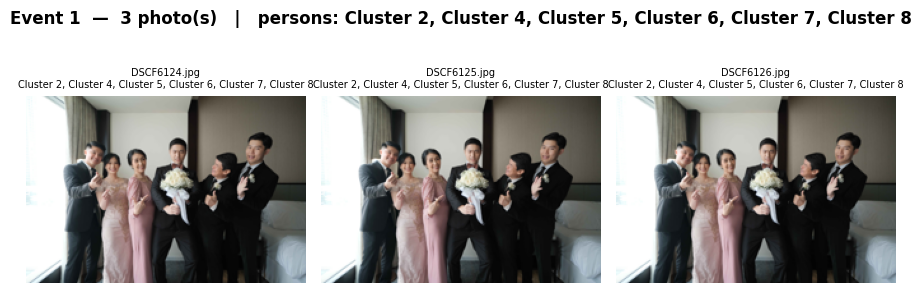

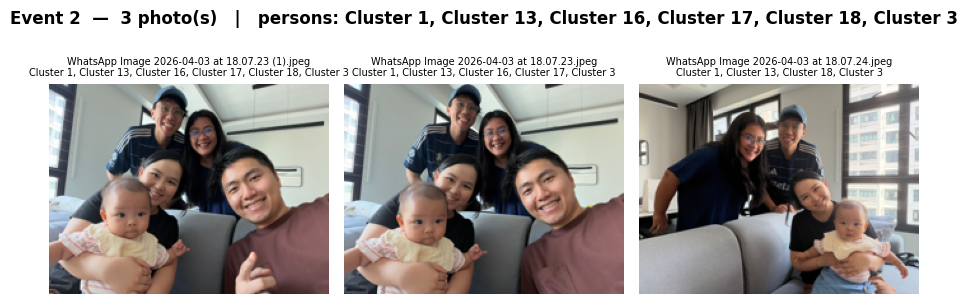

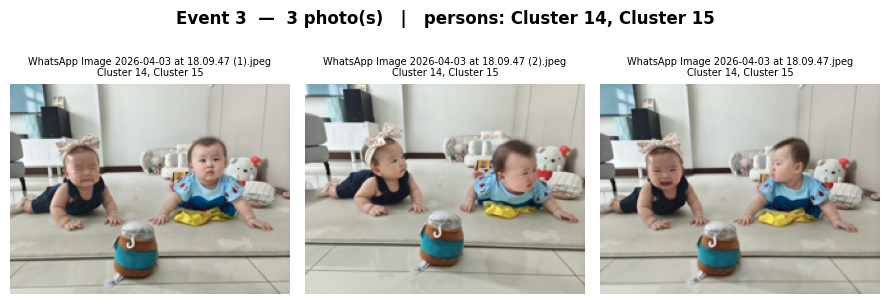

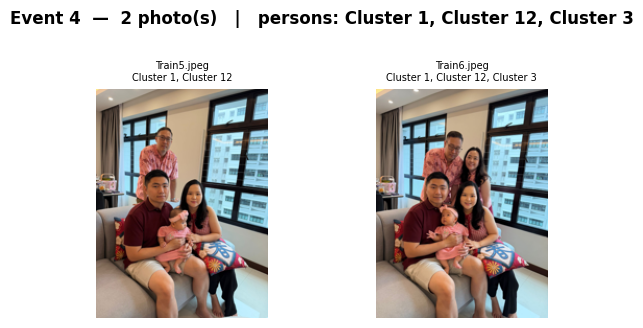

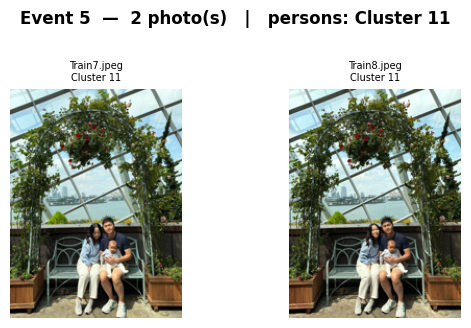

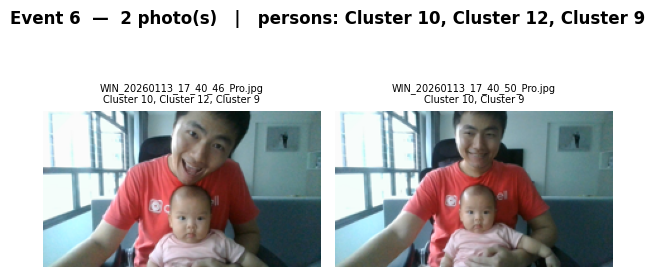

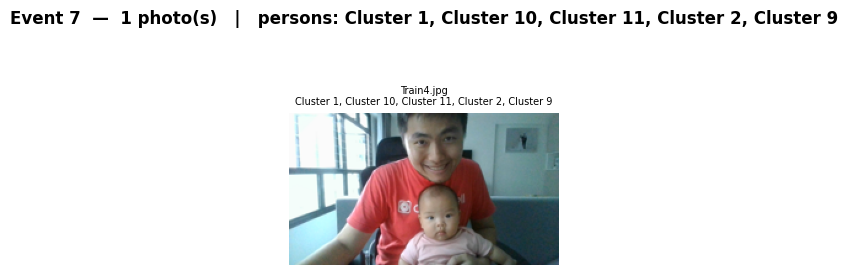

In [71]:
# ── Cell 14e: Visual Display — Final Image Event Clusters ────────────────────
# Display all images in each event cluster as a thumbnail grid.

THUMB_W, THUMB_H = 220, 220
MAX_COLS         = 5   # max thumbnails per row

for i, cluster_paths in enumerate(event_clusters, start=1):
    n = len(cluster_paths)
    n_cols = min(n, MAX_COLS)
    n_rows = (n + n_cols - 1) // n_cols

    # Collect person labels for title
    all_pids = set()
    for p in cluster_paths:
        all_pids.update(image_to_persons.get(str(p), set()))
    person_labels = ", ".join(sorted(pid_to_rank.get(pid, pid) for pid in all_pids))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))
    axes = np.array(axes).reshape(-1)   # flatten for easy indexing

    fig.suptitle(
        f"Event {i}  —  {n} photo(s)   |   persons: {person_labels}",
        fontsize=12, fontweight="bold", y=1.01,
    )

    for ax, photo_path in zip(axes, cluster_paths):
        img = Image.open(photo_path).convert("RGB")
        img.thumbnail((THUMB_W, THUMB_H))
        # Show which persons are in this specific image
        pids_here = sorted(pid_to_rank.get(pid, pid)
                           for pid in image_to_persons.get(str(photo_path), set()))
        ax.imshow(img)
        ax.set_title(f"{photo_path.name}\n{', '.join(pids_here)}", fontsize=7)
        ax.axis("off")

    for ax in axes[n:]:   # hide unused subplot slots
        ax.axis("off")

    plt.tight_layout()
    plt.show()

---
# Section F: Aesthetic Quality — NIMA

NIMA predicts human aesthetic ratings (1–10 scale). It captures composition, lighting, and colour harmony — things the face-level signals miss.


Loading pretrained model NIMA from C:\Users\agust\.cache\torch\hub\pyiqa\NIMA_InceptionV2_ava-b0c77c00.pth
NIMA model loaded on cpu
Loaded NIMA cache: 19 entries


NIMA scoring: 100%|██████████| 19/19 [00:00<?, ?it/s]


  NIMA Aesthetic Scores
  Count   : 19
  Mean    : 3.8383
  Std     : 0.3302
  Min     : 3.2663
  Max     : 4.8781
  Median  : 3.7614


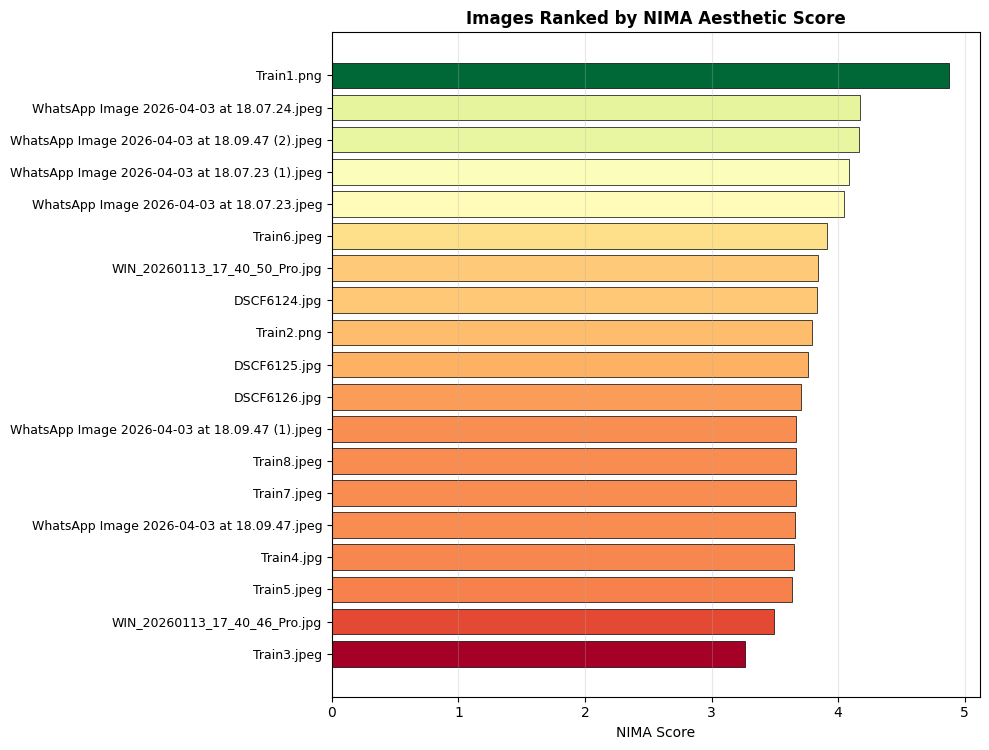

In [72]:
# ── Cell 18: NIMA Aesthetic Scoring ──────────────────────────────────────────
import pyiqa

nima_metric = pyiqa.create_metric("nima", device=DEVICE)
print(f"NIMA model loaded on {DEVICE}")

# ── Score all images (with disk cache) ───────────────────────────────────────
nima_cache_path = cfg.output_dir / "nima_scores.json"
if nima_cache_path.exists():
    with open(nima_cache_path) as f:
        nima_scores_cache = json.load(f)
    print(f"Loaded NIMA cache: {len(nima_scores_cache)} entries")
else:
    nima_scores_cache = {}

nima_scores: Dict[str, float] = {}
for path in tqdm(image_paths, desc="NIMA scoring"):
    key = str(path)
    if key in nima_scores_cache:
        nima_scores[key] = nima_scores_cache[key]
    else:
        img = Image.open(path).convert("RGB")
        # pyiqa expects a tensor
        transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
        img_tensor = transform(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            score = nima_metric(img_tensor).item()
        nima_scores[key] = score

# Save cache
with open(nima_cache_path, "w") as f:
    json.dump(nima_scores, f, indent=2)

# ── Descriptive statistics ───────────────────────────────────────────────────
scores_arr = np.array(list(nima_scores.values()))
print(f"\n{'='*60}")
print(f"  NIMA Aesthetic Scores")
print(f"{'='*60}")
print(f"  Count   : {len(scores_arr)}")
print(f"  Mean    : {scores_arr.mean():.4f}")
print(f"  Std     : {scores_arr.std():.4f}")
print(f"  Min     : {scores_arr.min():.4f}")
print(f"  Max     : {scores_arr.max():.4f}")
print(f"  Median  : {np.median(scores_arr):.4f}")
print(f"{'='*60}")

# ── Horizontal bar chart ─────────────────────────────────────────────────────
sorted_items = sorted(nima_scores.items(), key=lambda x: x[1], reverse=True)
names = [Path(p).name for p, _ in sorted_items]
vals = [v for _, v in sorted_items]

fig, ax = plt.subplots(figsize=(10, max(3, len(names) * 0.4)))
colors = plt.cm.RdYlGn(minmax_norm(np.array(vals)))
ax.barh(range(len(names)), vals, color=colors, edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("NIMA Score")
ax.set_title("Images Ranked by NIMA Aesthetic Score", fontweight="bold")
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

---
# Section G: Multi-Signal Scoring

## Scoring Formula
```
finalScore = 0.25 × centrality      (DINOv2 embedding closeness to group centroid)
           + 0.15 × face_sharpness  (Laplacian variance on face crop)
           + 0.10 × face_size       (face bbox area / image area)
           + 0.10 × det_score       (InsightFace detection confidence)
           + 0.10 × pose            (frontal face penalty)
           + 0.05 × ear             (eye aspect ratio — penalises blinks)
           + 0.25 × nima            (NIMA aesthetic score)
```

All signals are min-max normalised within each identity group before combining.


In [73]:
# Cell 20: Score & Rank Per Event Cluster
photo_to_faces = {}
for rec in face_records:
    photo_to_faces.setdefault(str(rec['photo_path']), []).append(rec)

person_photo_to_faces = {}
for rec in face_records:
    pid = rec.get('person_id')
    if pid is None:
        continue
    person_photo_to_faces.setdefault((pid, str(rec['photo_path'])), []).append(rec)


def best_face_signals(pid, path):
    recs = person_photo_to_faces.get((pid, str(path)), photo_to_faces.get(str(path), []))
    if not recs:
        return {'det_score': 0, 'pose_penalty': 0.5, 'ear': 0.5, 'face_sharpness': 0, 'face_size_ratio': 0}
    best = max(recs, key=lambda r: r.get('det_score', 0))
    return {
        'det_score':       best.get('det_score', 0),
        'pose_penalty':    best.get('pose_penalty', 0.5),
        'ear':             best.get('ear', 0.5),
        'face_sharpness':  best.get('face_sharpness', 0),
        'face_size_ratio': best.get('face_size_ratio', 0),
    }


def score_event_group(event_id, photos):
    valid = [p for p in photos if str(p) in path_to_dino_idx]
    if not valid:
        return pd.DataFrame()
    idxs       = [path_to_dino_idx[str(p)] for p in valid]
    vecs       = dino_embeddings[idxs]
    centroid   = vecs.mean(axis=0, keepdims=True)
    dists      = np.linalg.norm(vecs - centroid, axis=1)
    centrality = 1.0 - minmax_norm(dists)
    rows = []
    for i, path in enumerate(valid):
        persons_in_photo = [
            prec['person_id'] for prec in person_detections
            if str(prec['photo_path']) == str(path) and prec.get('person_id')
        ]
        pid_for_signals = persons_in_photo[0] if persons_in_photo else None
        fs = best_face_signals(pid_for_signals, path) if pid_for_signals else {
            'det_score': 0, 'pose_penalty': 0.5, 'ear': 0.5, 'face_sharpness': 0, 'face_size_ratio': 0}
        ns = nima_scores.get(str(path), 0.0)
        rows.append({
            'event_id':           event_id,
            'photo_path':         str(path),
            'centrality_raw':     float(centrality[i]),
            'face_sharpness_raw': fs['face_sharpness'],
            'face_size_raw':      fs['face_size_ratio'],
            'det_score_raw':      fs['det_score'],
            'pose_raw':           fs['pose_penalty'],
            'ear_raw':            fs['ear'],
            'nima_raw':           ns,
        })
    df = pd.DataFrame(rows)
    for sig in ['centrality', 'face_sharpness', 'face_size', 'det_score', 'pose', 'ear', 'nima']:
        df[f'{sig}_norm'] = minmax_norm(df[f'{sig}_raw'].values)
    df['final_score'] = (
        cfg.w_centrality       * df['centrality_norm']
        + cfg.w_face_sharpness * df['face_sharpness_norm']
        + cfg.w_face_size      * df['face_size_norm']
        + cfg.w_det_score      * df['det_score_norm']
        + cfg.w_pose           * df['pose_norm']
        + cfg.w_ear            * df['ear_norm']
        + cfg.w_nima           * df['nima_norm']
    )
    return df.sort_values('final_score', ascending=False).reset_index(drop=True)


all_group_dfs = {}
best_photos   = {}

for event_idx, cluster_paths in enumerate(tqdm(event_clusters, desc='Scoring events'), start=1):
    event_id = f'event_{event_idx}'
    gdf = score_event_group(event_id, cluster_paths)
    if gdf.empty:
        continue
    all_group_dfs[event_id] = gdf
    best_photos[event_id]   = gdf.iloc[0]['photo_path']

print(f'Scoring complete -- {len(all_group_dfs)} event clusters scored')
for eid, gdf in all_group_dfs.items():
    best_name   = Path(gdf.iloc[0]['photo_path']).name
    score       = gdf.iloc[0]['final_score']
    lo, hi      = gdf['final_score'].min(), gdf['final_score'].max()
    print(f'  {eid:<14} {len(gdf):>4} photos   best={best_name}   score={score:.4f}   range={lo:.3f}-{hi:.3f}')


Scoring events: 100%|██████████| 7/7 [00:00<00:00, 164.98it/s]

Scoring complete -- 7 event clusters scored
  event_1           3 photos   best=DSCF6124.jpg   score=0.6050   range=0.261-0.605
  event_2           3 photos   best=WhatsApp Image 2026-04-03 at 18.07.23.jpeg   score=0.6032   range=0.450-0.603
  event_3           3 photos   best=WhatsApp Image 2026-04-03 at 18.09.47 (1).jpeg   score=0.4535   range=0.359-0.454
  event_4           2 photos   best=Train6.jpeg   score=0.7000   range=0.550-0.700
  event_5           2 photos   best=Train7.jpeg   score=0.6500   range=0.600-0.650
  event_6           2 photos   best=WIN_20260113_17_40_50_Pro.jpg   score=0.9000   range=0.350-0.900
  event_7           1 photos   best=Train4.jpg   score=1.0000   range=1.000-1.000


C:\Users\agust\AppData\Local\Temp\ipykernel_4912\707421655.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


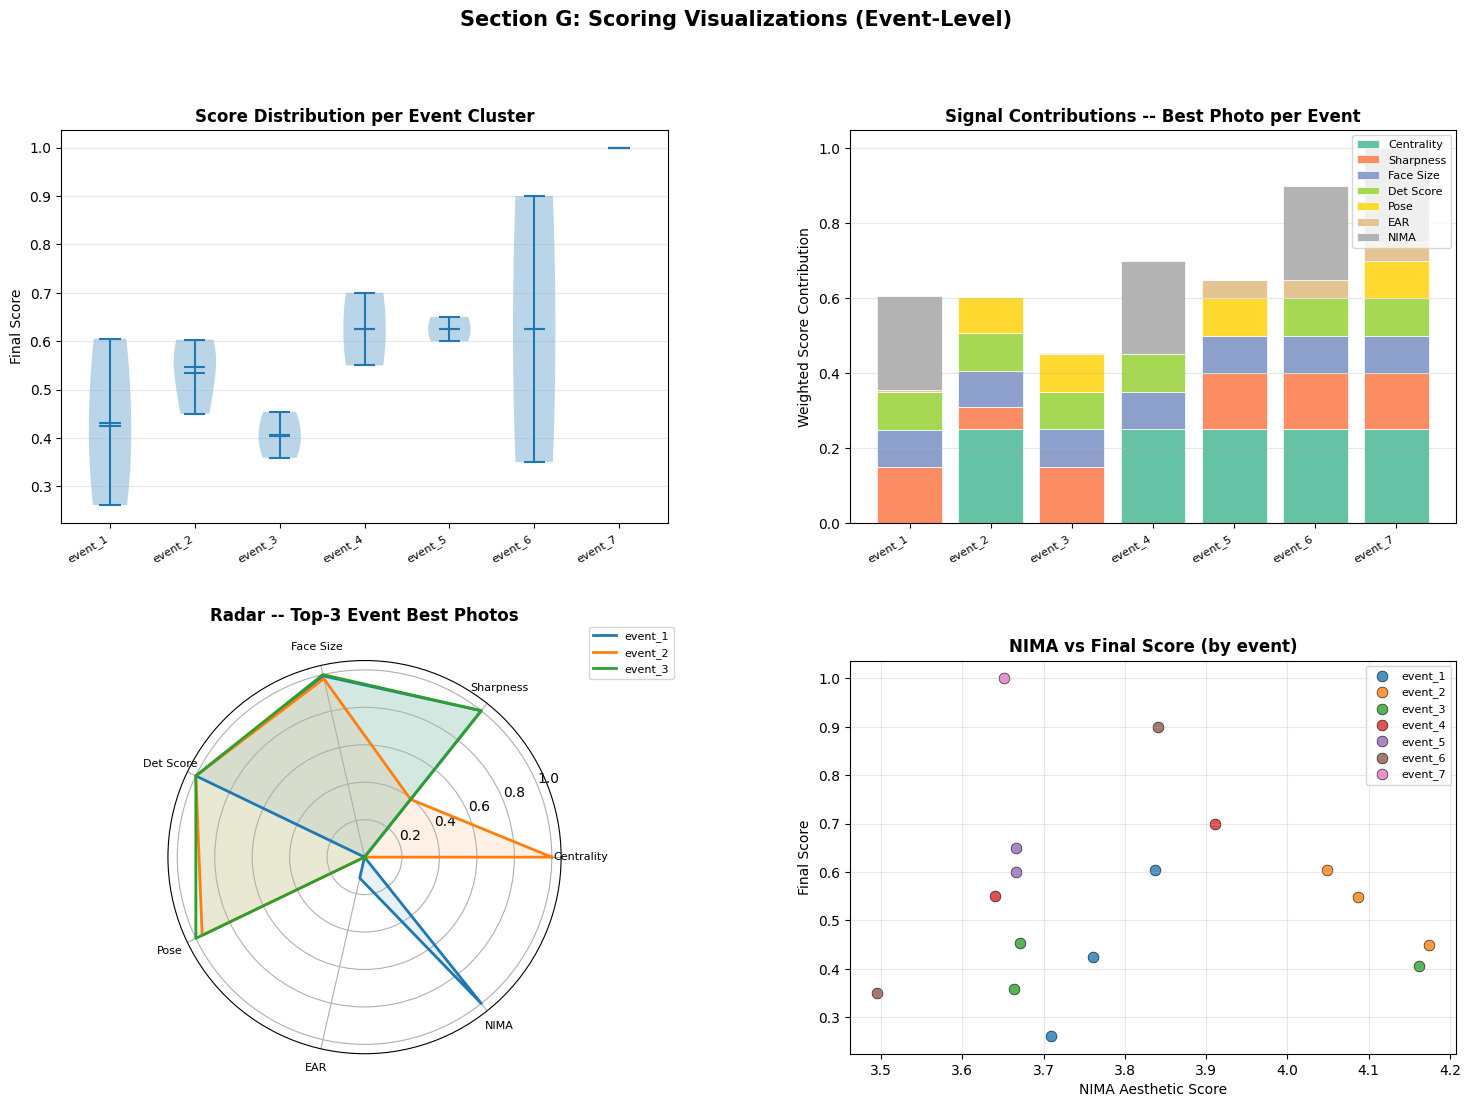

In [74]:
# Cell 21: Score Visualizations (Event-Level)
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

event_ids  = list(all_group_dfs.keys())
score_data = [all_group_dfs[eid]['final_score'].values for eid in event_ids]

ax1 = fig.add_subplot(gs[0, 0])
if any(len(s) > 1 for s in score_data):
    ax1.violinplot(score_data, showmeans=True, showmedians=True)
    ax1.set_xticks(range(1, len(event_ids) + 1))
    ax1.set_xticklabels(event_ids, rotation=30, ha='right', fontsize=8)
else:
    means = [s.mean() for s in score_data]
    ax1.bar(range(len(event_ids)), means, color='steelblue', edgecolor='black')
    ax1.set_xticks(range(len(event_ids)))
    ax1.set_xticklabels(event_ids, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('Final Score')
ax1.set_title('Score Distribution per Event Cluster', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

ax2 = fig.add_subplot(gs[0, 1])
signal_cols   = ['centrality_norm', 'face_sharpness_norm', 'face_size_norm',
                 'det_score_norm', 'pose_norm', 'ear_norm', 'nima_norm']
weight_vals   = [cfg.w_centrality, cfg.w_face_sharpness, cfg.w_face_size,
                 cfg.w_det_score, cfg.w_pose, cfg.w_ear, cfg.w_nima]
signal_labels = ['Centrality', 'Sharpness', 'Face Size', 'Det Score', 'Pose', 'EAR', 'NIMA']
colors_stack  = plt.cm.Set2(np.linspace(0, 1, len(signal_cols)))
bottoms = np.zeros(len(event_ids))
for col, w, label, c in zip(signal_cols, weight_vals, signal_labels, colors_stack):
    vals = [all_group_dfs[eid].iloc[0][col] * w for eid in event_ids]
    ax2.bar(range(len(event_ids)), vals, bottom=bottoms, label=label, color=c, edgecolor='white', linewidth=0.5)
    bottoms += np.array(vals)
ax2.set_xticks(range(len(event_ids)))
ax2.set_xticklabels(event_ids, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Weighted Score Contribution')
ax2.set_title('Signal Contributions -- Best Photo per Event', fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig.add_subplot(gs[1, 0], polar=True)
top_eids = event_ids[:min(3, len(event_ids))]
angles   = np.linspace(0, 2 * np.pi, len(signal_labels), endpoint=False).tolist()
angles  += angles[:1]
for eid in top_eids:
    row    = all_group_dfs[eid].iloc[0]
    values = [row[c] for c in signal_cols] + [row[signal_cols[0]]]
    ax3.plot(angles, values, label=eid, linewidth=2)
    ax3.fill(angles, values, alpha=0.1)
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(signal_labels, fontsize=8)
ax3.set_title('Radar -- Top-3 Event Best Photos', fontweight='bold', pad=15)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

ax4 = fig.add_subplot(gs[1, 1])
for eid in event_ids:
    gdf = all_group_dfs[eid]
    ax4.scatter(gdf['nima_raw'], gdf['final_score'], label=eid, s=60, edgecolors='black', linewidths=0.5, alpha=0.8)
ax4.set_xlabel('NIMA Aesthetic Score')
ax4.set_ylabel('Final Score')
ax4.set_title('NIMA vs Final Score (by event)', fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.suptitle('Section G: Scoring Visualizations (Event-Level)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Section H: Evaluation & Analysis

1. **Ablation** — drop one signal at a time, measure ranking stability (Kendall tau)
2. **UMAP** — 2D projections of ReID and DINOv2 embeddings
3. **Correlation heatmap** — Pearson r across all 7 signals


Ablation Study -- Remove One Signal at a Time (Event-Level)
Removed Signal  Weight  Kendall tau  Top-1 Changes
    Centrality  0.2500       0.6667              1
     Sharpness  0.1500       0.3333              3
     Face Size  0.1000       0.3333              2
     Det Score  0.1000       0.7778              2
          Pose  0.1000       0.4444              2
           EAR  0.0500       1.0000              0
          NIMA  0.2500       0.5556              1


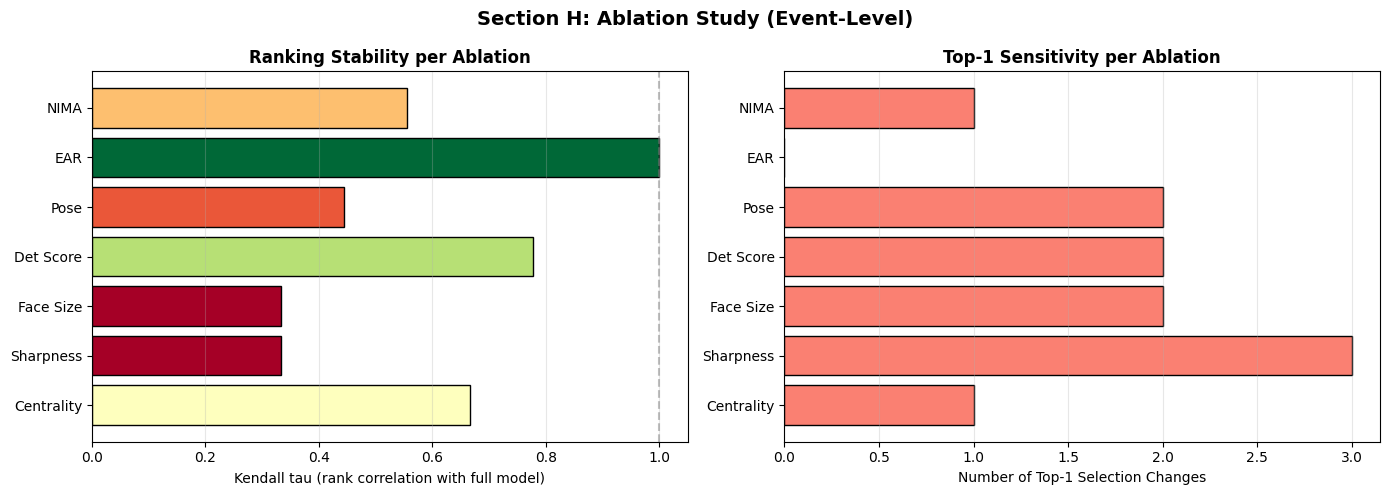

In [75]:
# Cell 23: Ablation Study (Event-Level)

full_rankings  = {eid: gdf['photo_path'].tolist() for eid, gdf in all_group_dfs.items()}
weight_names   = ['w_centrality', 'w_face_sharpness', 'w_face_size', 'w_det_score', 'w_pose', 'w_ear', 'w_nima']
signal_display = ['Centrality', 'Sharpness', 'Face Size', 'Det Score', 'Pose', 'EAR', 'NIMA']

ablation_results = []
for wi, wname in enumerate(weight_names):
    orig_weights = {wn: getattr(cfg, wn) for wn in weight_names}
    mod_weights  = orig_weights.copy()
    removed_val  = mod_weights[wname]
    mod_weights[wname] = 0.0
    remaining = sum(mod_weights.values())
    if remaining > 0:
        for k in mod_weights:
            if k != wname:
                mod_weights[k] *= (1.0 / remaining)
    tau_values   = []
    top1_changes = 0
    for eid, gdf in all_group_dfs.items():
        if len(gdf) < 2:
            continue
        new_score = (
            mod_weights['w_centrality']       * gdf['centrality_norm']
            + mod_weights['w_face_sharpness'] * gdf['face_sharpness_norm']
            + mod_weights['w_face_size']      * gdf['face_size_norm']
            + mod_weights['w_det_score']      * gdf['det_score_norm']
            + mod_weights['w_pose']           * gdf['pose_norm']
            + mod_weights['w_ear']            * gdf['ear_norm']
            + mod_weights['w_nima']           * gdf['nima_norm']
        )
        new_order = gdf.assign(new_score=new_score).sort_values('new_score', ascending=False)['photo_path'].tolist()
        old_order = full_rankings[eid]
        if len(old_order) >= 2:
            rank_old = {p: i for i, p in enumerate(old_order)}
            rank_new = {p: i for i, p in enumerate(new_order)}
            common   = [p for p in old_order if p in rank_new]
            if len(common) >= 2:
                tau, _ = kendalltau([rank_old[p] for p in common], [rank_new[p] for p in common])
                tau_values.append(tau)
        if old_order[0] != new_order[0]:
            top1_changes += 1
    avg_tau = np.mean(tau_values) if tau_values else float('nan')
    ablation_results.append({'Removed Signal': signal_display[wi], 'Weight': removed_val,
                              'Kendall tau': avg_tau, 'Top-1 Changes': top1_changes})

abl_df = pd.DataFrame(ablation_results)
print('Ablation Study -- Remove One Signal at a Time (Event-Level)')
print('=' * 65)
print(abl_df.to_string(index=False, float_format='%.4f'))
print('=' * 65)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.RdYlGn(minmax_norm(abl_df['Kendall tau'].fillna(0).values))
ax1.barh(range(len(abl_df)), abl_df['Kendall tau'].fillna(0), color=colors, edgecolor='black')
ax1.set_yticks(range(len(abl_df)))
ax1.set_yticklabels(abl_df['Removed Signal'])
ax1.set_xlabel('Kendall tau (rank correlation with full model)')
ax1.set_title('Ranking Stability per Ablation', fontweight='bold')
ax1.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='x')
ax2.barh(range(len(abl_df)), abl_df['Top-1 Changes'], color='salmon', edgecolor='black')
ax2.set_yticks(range(len(abl_df)))
ax2.set_yticklabels(abl_df['Removed Signal'])
ax2.set_xlabel('Number of Top-1 Selection Changes')
ax2.set_title('Top-1 Sensitivity per Ablation', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
plt.suptitle('Section H: Ablation Study (Event-Level)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

c:\Users\agust\AppData\Local\miniconda3\envs\lumina\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\agust\AppData\Local\miniconda3\envs\lumina\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


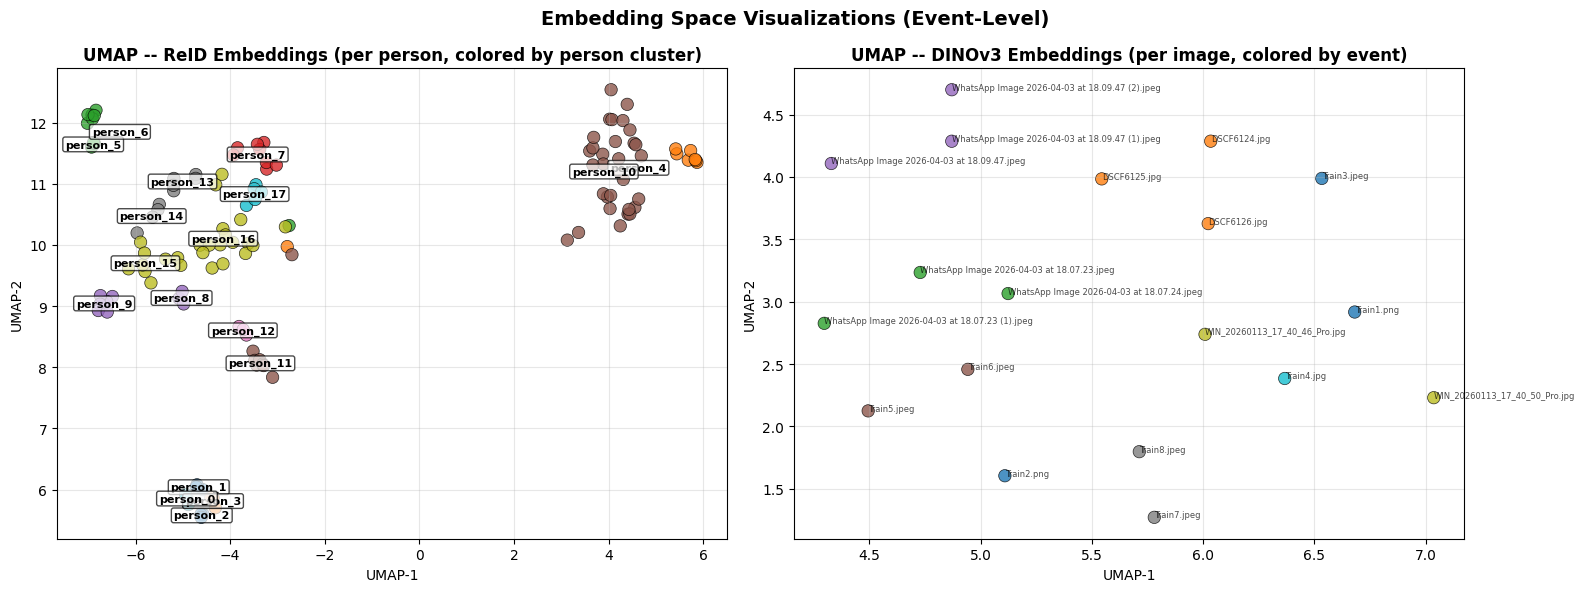

In [77]:
# Cell 25: UMAP Embedding Visualizations (Event-Level)
import umap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: ReID embeddings colored by person cluster (person_id), not event
unique_pids = sorted(set(r.get('person_id') for r in person_detections if r.get('person_id') is not None), key=lambda x: (str(x).replace('person_', '').isdigit() and int(str(x).replace('person_', '')) or 999, str(x)))
pid_to_color = {pid: i for i, pid in enumerate(unique_pids)}
person_colors = [pid_to_color.get(r.get('person_id'), -1) for r in person_detections]

# Right plot: DINOv2 colored by event (photo -> event mapping)
photo_to_event = {}
for event_idx, cluster_paths in enumerate(event_clusters, start=1):
    eid = f'event_{event_idx}'
    for p in cluster_paths:
        photo_to_event[str(p)] = eid
unique_eids = sorted(set(photo_to_event.values()))
eid_to_color = {eid: i for i, eid in enumerate(unique_eids)}

if reid_embeddings.shape[0] >= 3:
    reducer_reid = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=min(15, len(reid_embeddings) - 1))
    reid_2d = reducer_reid.fit_transform(reid_embeddings)
    ax1.scatter(reid_2d[:, 0], reid_2d[:, 1], c=person_colors, cmap='tab10', s=80, edgecolors='black', linewidths=0.5, alpha=0.8)
    for pid in unique_pids:
        idxs = [i for i, r in enumerate(person_detections) if r.get('person_id') == pid]
        if idxs:
            ax1.annotate(pid, (reid_2d[idxs, 0].mean(), reid_2d[idxs, 1].mean()),
                         fontsize=8, fontweight='bold', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
else:
    ax1.text(0.5, 0.5, 'Too few detections for UMAP', transform=ax1.transAxes, ha='center')
ax1.set_title('UMAP -- ReID Embeddings (per person, colored by person cluster)', fontweight='bold')
ax1.set_xlabel('UMAP-1'); ax1.set_ylabel('UMAP-2'); ax1.grid(True, alpha=0.3)

img_event_colors = [eid_to_color.get(photo_to_event.get(str(p), ''), -1) for p in image_paths]
if dino_embeddings.shape[0] >= 3:
    reducer_dino = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=min(15, len(dino_embeddings) - 1))
    dino_2d = reducer_dino.fit_transform(dino_embeddings)
    ax2.scatter(dino_2d[:, 0], dino_2d[:, 1], c=img_event_colors, cmap='tab10', s=80, edgecolors='black', linewidths=0.5, alpha=0.8)
    for i, p in enumerate(image_paths):
        ax2.annotate(p.name, (dino_2d[i, 0], dino_2d[i, 1]), fontsize=6, alpha=0.7)
else:
    ax2.text(0.5, 0.5, 'Too few images for UMAP', transform=ax2.transAxes, ha='center')
ax2.set_title('UMAP -- DINOv2 Embeddings (per image, colored by event)', fontweight='bold')
ax2.set_xlabel('UMAP-1'); ax2.set_ylabel('UMAP-2'); ax2.grid(True, alpha=0.3)

plt.suptitle('Embedding Space Visualizations (Event-Level)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

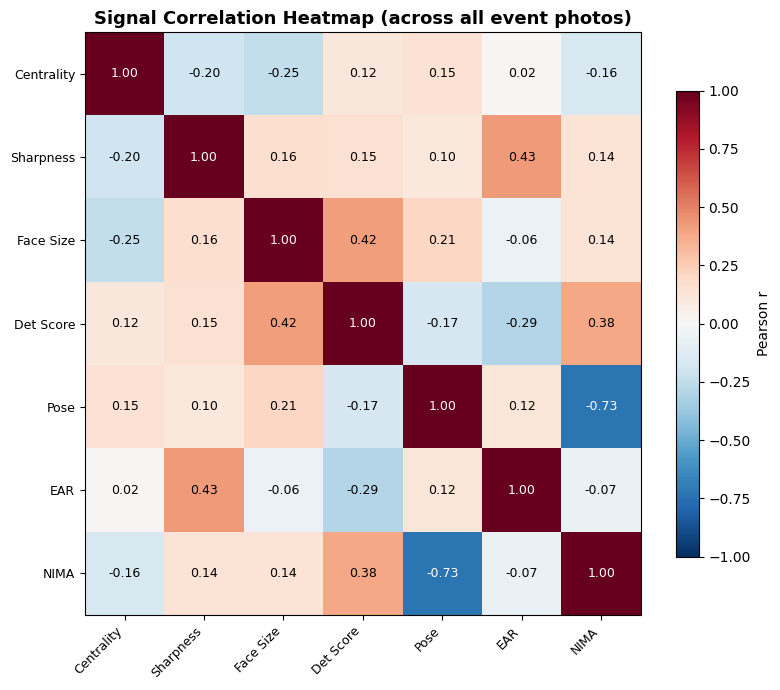

In [78]:
# Cell 26: Signal Correlation Heatmap (Event-Level)
corr_rows = []
for eid, gdf in all_group_dfs.items():
    for _, row in gdf.iterrows():
        corr_rows.append({
            'Centrality': row['centrality_norm'],
            'Sharpness':  row['face_sharpness_norm'],
            'Face Size':  row['face_size_norm'],
            'Det Score':  row['det_score_norm'],
            'Pose':       row['pose_norm'],
            'EAR':        row['ear_norm'],
            'NIMA':       row['nima_norm'],
        })
corr_df = pd.DataFrame(corr_rows)
if len(corr_df) >= 3:
    corr_matrix = corr_df.corr(method='pearson')
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            val   = corr_matrix.values[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(corr_matrix.columns, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
    ax.set_title('Signal Correlation Heatmap (across all event photos)', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data points for correlation analysis.')

---
# Section I: Results & Export

Final outputs: contact sheets with annotations, summary dashboard, and exported JSON/CSV/best-photo files.
